# Polygenic Risk Score (PRS) Modifies Penetrance of Pathogenic Variants in Hypertrophic Cardiomyopathy (HCM)

## Overview
This notebook investigates whether polygenic risk score (PRS) influences the penetrance of pathogenic variants in HCM-associated genes. We hypothesize that individuals carrying pathogenic variants with higher PRS backgrounds have increased disease penetrance compared to those with lower PRS backgrounds.

---

## Study Design
**Research Question**: Does polygenic background modify the penetrance of rare pathogenic variants in HCM?

**Approach**:
1. Identify individuals with pathogenic variants in HCM genes
2. Calculate genome-wide PRS for HCM using weights from Harper et al. (Nature Genetics, 2024)
3. Determine HCM case/control status using OMOP Common Data Model phenotype data
4. Test whether PRS is associated with HCM diagnosis among pathogenic variant carriers
---

## Data Sources

### Genotype Data
- **Source**: VUMC BioVU Biobank via NashBio
- **Format**: PLINK binary files (`.bed/.bim/.fam`)
- **Content**: Whole-genome sequencing data

### PRS Weights
- **Source**: Harper et al., *Nature Genetics* (2024) - "Genome-wide association study identifies 30 loci associated with hypertrophic cardiomyopathy"
- **Method**: Effect sizes (beta coefficients) from GWAS meta-analysis
- **Application**: Weighted sum of risk alleles across genome-wide significant loci

### Phenotype Data
- **Source**: OMOP Common Data Model tables (`condition_occurrence`, `person`, etc.)
- **HCM Definition**: ICD-10 code I42.1 or I42.2 (Obstructive/Non-obstructive HCM)
- **Case Definition**: ≥2 HCM diagnosis codes in EHR on dates ≥1 day apart 
- **Control Definition**: No HCM diagnosis codes

### Pathogenic Variant Data
- **Genes**: *MYBPC3*, *MYH7*, and other HCM-associated genes source from Invitae HCM panel
- **Classification**: Pathogenic (P) per ClinVar guidelines
- **Source**: ClinVar

---

## Key Hypotheses

**Primary Hypothesis**: 

**Secondary Hypotheses**:

---

## Analytical Pipeline

### 1. **PRS Calculation**
- Apply Harper et al. GWAS weights to individual genotypes

### 2. **Phenotype Extraction**

### 3. **Statistical Analysis**

### 4. **Visualization & Interpretation**
---

## Important Considerations

 **Penetrance Definition**: Penetrance estimates depend on accurate phenotyping. OMOP-based definitions may miss subclinical or undiagnosed HCM cases.

 **Sample Size**: Statistical power depends on the number of pathogenic variant carriers with complete genotype and phenotype data.

 **Ascertainment Bias**: Biobank participants may differ from general population in health-seeking behavior and disease prevalence.

---

## Software & Dependencies
- **Python 3.x**: pandas, numpy, scipy, matplotlib, seaborn, scikit-learn
- **PLINK 1.9/2.0**: Genotype QC and PRS calculation
- **SQL/BigQuery**: OMOP phenotype extraction
- **R (optional)**: Additional statistical modeling and visualization

---

**Author**: Melanie Fernandez 
**Institution**: NashBio  
**Date**: 8/18/2026 
**Project**: HCM Polygenic Background and Variant Penetrance Study

---

In [ ]:
#Insert cohort definition code - get code from dev - need special link from Cole

# HCM Polygenic Risk Score (PRS) Calculation

This sectio of the notebook maps PRS variants to GRCh38, extracts genotypes, and calculates polygenic risk scores for the HCM cohort and controls.

**Data Source:** NashBio Biobank  
**PRS Model:** PGS000739

In [5]:
import os
import pandas as pd
import subprocess
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time

# File paths - update accordingly
CHROM_BASE_PATH = "/home/jupyter/gcs"
PRS_VARIANTS_FILE = "/home/jupyter/PGS000739.txt"
PATIENT_ID_FILE = "/home/jupyter/hcm_person_ids.csv" 
PATIENT_ID_COLUMN = "PERSON_ID"
# Use command "where plink2" to update plink2 path
PLINK2_PATH = "/opt/conda/envs/mf_cm/bin/plink2"

# Output directory
OUTPUT_DIR = "/home/jupyter/prs_hcm_experiment"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [6]:
# Match HCM patient IDs with samples in the genotype data
# Load reference PSAM file (using chr1 as reference)
REFERENCE_PSAM = f"{CHROM_BASE_PATH}/chrom-1/postproc-pgen/dragen.psam"
psam_df = pd.read_csv(REFERENCE_PSAM, sep='\t')

# Clean column names
if '#FID' in psam_df.columns:
    psam_df.rename(columns={'#FID': 'FID'}, inplace=True)

print(f"Loaded {len(psam_df):,} total samples from genotype data")

# Load HCM patient IDs
patient_df = pd.read_csv(PATIENT_ID_FILE)
patient_ids = patient_df[PATIENT_ID_COLUMN].astype(str).tolist()
print(f"Loaded {len(patient_ids):,} HCM patient IDs")

# Match patient IDs with genotype samples
patient_ids_set = set(patient_ids)
psam_df['FID_str'] = psam_df['FID'].astype(str)
psam_df['IID_str'] = psam_df['IID'].astype(str)

matched_samples = psam_df[psam_df['IID_str'].isin(patient_ids_set)].copy()
print(f" Matched {len(matched_samples):,} HCM patients to genotype data")

# Report missing IDs
if len(matched_samples) < len(patient_ids):
    missing_count = len(patient_ids) - len(matched_samples)
    print(f"   Warning: {missing_count} patient IDs not found in genotype data")

# Save HCM cohort keep file for PLINK
hcm_keep_file = f"{OUTPUT_DIR}/hcm_cohort.keep"
matched_samples[['FID', 'IID']].to_csv(hcm_keep_file, sep='\t', header=False, index=False)

print(f"\nCohort Summary:")
print(f"  Total samples in dataset: {len(psam_df):,}")
print(f"  HCM cases: {len(matched_samples):,}")
print(f"  Controls: {len(psam_df) - len(matched_samples):,}")

Loaded 250,115 total samples from genotype data
Loaded 1,723 HCM patient IDs
 Matched 331 HCM patients to genotype data

Cohort Summary:
  Total samples in dataset: 250,115
  HCM cases: 331
  Controls: 249,784


In [19]:
# Convert rsIDs to chr:pos:ref:alt format (GRCh38)
# Query Ensembl REST API to get genomic coordinates and alleles

import requests
import time
from datetime import datetime

print(f"Convert rsIDs to GRCh38 Coordinates")

# Configuration
PRS_VARIANTS_FILE = "/home/jupyter/PGS000739.txt"
ENSEMBL_API_URL = "https://rest.ensembl.org/variation/homo_sapiens"
BATCH_SIZE = 200
REQUEST_TIMEOUT = 30
RATE_LIMIT_DELAY = 0.5  # seconds between requests

# Load PRS weights
print(f"Loading PRS weights file...")
prs_df = pd.read_csv(PRS_VARIANTS_FILE, sep='\t')

print(f" Loaded {len(prs_df):,} variants")
print(f"  Columns: {', '.join(prs_df.columns)}")

# Function to query Ensembl in batches
def get_variant_info_batch(rsids, batch_size=BATCH_SIZE):
    """Query Ensembl REST API for variant information in batches"""
    results = {}
    failed_batches = []
    
    n_batches = (len(rsids) + batch_size - 1) // batch_size
    
    for i in range(0, len(rsids), batch_size):
        batch = rsids[i:i+batch_size]
        batch_num = i // batch_size + 1
        
        print(f"  Batch {batch_num}/{n_batches} ({len(batch)} rsIDs)...", end=' ')
        
        headers = {"Content-Type": "application/json"}
        data = {"ids": batch}
        
        try:
            response = requests.post(
                ENSEMBL_API_URL, 
                json=data, 
                headers=headers, 
                timeout=REQUEST_TIMEOUT
            )
            
            if response.status_code == 200:
                variant_data = response.json()
                batch_success = 0
                
                for rsid, info in variant_data.items():
                    if 'mappings' in info:
                        # Find GRCh38 mapping
                        for mapping in info['mappings']:
                            if mapping.get('assembly_name') == 'GRCh38':
                                allele_string = mapping.get('allele_string', '')
                                alleles = allele_string.split('/')
                                
                                # Must have at least ref and one alt allele
                                if len(alleles) >= 2:
                                    results[rsid] = {
                                        'chr': f"chr{mapping['seq_region_name']}",
                                        'pos': mapping['start'],
                                        'ref': alleles[0],
                                        'alt': alleles[1]
                                    }
                                    batch_success += 1
                                break
                
                print(f" {batch_success}/{len(batch)} mapped")
                
            elif response.status_code == 429:
                print(f" Rate limited")
                failed_batches.append((i, batch))
                time.sleep(5)  # Wait longer for rate limit
                
            else:
                print(f" HTTP {response.status_code}")
                failed_batches.append((i, batch))
                
        except requests.exceptions.Timeout:
            print(f" Timeout")
            failed_batches.append((i, batch))
            
        except Exception as e:
            print(f" {type(e).__name__}: {str(e)[:50]}")
            failed_batches.append((i, batch))
        
        # Rate limiting
        time.sleep(RATE_LIMIT_DELAY)
    
    # Retry failed batches once
    if failed_batches:
        print(f"\n  Retrying {len(failed_batches)} failed batches...")
        time.sleep(2)
        
        for batch_idx, batch in failed_batches:
            batch_num = batch_idx // batch_size + 1
            print(f"    Retry batch {batch_num}...", end=' ')
            
            try:
                response = requests.post(
                    ENSEMBL_API_URL,
                    json={"ids": batch},
                    headers={"Content-Type": "application/json"},
                    timeout=REQUEST_TIMEOUT
                )
                
                if response.status_code == 200:
                    variant_data = response.json()
                    retry_success = 0
                    
                    for rsid, info in variant_data.items():
                        if rsid not in results and 'mappings' in info:
                            for mapping in info['mappings']:
                                if mapping.get('assembly_name') == 'GRCh38':
                                    allele_string = mapping.get('allele_string', '')
                                    alleles = allele_string.split('/')
                                    
                                    if len(alleles) >= 2:
                                        results[rsid] = {
                                            'chr': f"chr{mapping['seq_region_name']}",
                                            'pos': mapping['start'],
                                            'ref': alleles[0],
                                            'alt': alleles[1]
                                        }
                                        retry_success += 1
                                    break
                    
                    print(f" {retry_success} recovered")
                else:
                    print(f" Still failing")
                    
            except Exception as e:
                print(f" {type(e).__name__}")
            
            time.sleep(RATE_LIMIT_DELAY)
    
    return results


# Get unique rsIDs and query Ensembl
rsids = prs_df['rsID'].dropna().unique().tolist()
print(f"\nQuerying Ensembl for {len(rsids):,} unique rsIDs...")
print(f"Time: {datetime.now().strftime('%H:%M:%S')}\n")

start_time = time.time()
variant_info = get_variant_info_batch(rsids)
elapsed = time.time() - start_time

print(f"\n Query complete in {elapsed:.1f}s ({len(variant_info)/elapsed:.1f} variants/sec)")
print(f"  Successfully mapped: {len(variant_info):,} / {len(rsids):,} ({len(variant_info)/len(rsids)*100:.1f}%)")

print(f"\nBuilding output dataframe...")

mapped_variants = []

for _, row in prs_df.iterrows():
    rsid = row['rsID']
    
    if pd.notna(rsid) and rsid in variant_info:
        info = variant_info[rsid]
        
        # Determine effect allele orientation
        effect = str(row['effect_allele']).upper()
        ref = info['ref'].upper()
        alt = info['alt'].upper()
        
        # Only include if effect allele matches ref or alt
        if effect == alt:
            is_effect_alt = True
        elif effect == ref:
            is_effect_alt = False
        else:
            continue  # Skip mismatched variants
        
        # Build variant record
        mapped_variants.append({
            'rsID': rsid,
            'variant_id': f"{info['chr']}:{info['pos']}:{ref}:{alt}",
            'chr_name': info['chr'],
            'chr_position': int(info['pos']),
            'effect_allele': row['effect_allele'],
            'other_allele': row['other_allele'],
            'effect_weight': row['effect_weight'],
            'is_effect_alt': is_effect_alt
        })

# Create final dataframe
prs_export = pd.DataFrame(mapped_variants)

print(f" Effect allele matches ref/alt: {len(prs_export):,}")
print(f"  Effect = ALT: {prs_export['is_effect_alt'].sum():,}")
print(f"  Effect = REF: {(~prs_export['is_effect_alt']).sum():,}")

excluded_count = len(prs_df) - len(prs_export)
if excluded_count > 0:
    print(f"   Excluded {excluded_count} variants (mapping failed or allele mismatch)")

# Sort by chromosome and position
prs_export['chr_sort'] = prs_export['chr_name'].str.replace('chr', '').replace('X', '23').replace('Y', '24').replace('M', '25').astype(int)
prs_export = prs_export.sort_values(['chr_sort', 'chr_position']).drop(columns=['chr_sort']).reset_index(drop=True)


# Save results
output_file = f"{OUTPUT_DIR}/prs_weights_grch38.tsv"
prs_export.to_csv(output_file, sep='\t', index=False)

print(f"\nSUMMARY")
print(f"Successfully mapped to GRCh38: {len(prs_export):,} ({len(prs_export)/len(prs_df)*100:.1f}%)")
print(f"\nEffect weight distribution:")
print(f"  Min:    {prs_export['effect_weight'].min():.6f}")
print(f"  Median: {prs_export['effect_weight'].median():.6f}")
print(f"  Max:    {prs_export['effect_weight'].max():.6f}")

Convert rsIDs to GRCh38 Coordinates
Loading PRS weights file...
 Loaded 27 variants
  Columns: rsID, chr_name, chr_position, effect_allele, other_allele, effect_weight

Querying Ensembl for 27 unique rsIDs...
Time: 05:00:13

  Batch 1/1 (27 rsIDs)...  27/27 mapped

 Query complete in 5.6s (4.8 variants/sec)
  Successfully mapped: 27 / 27 (100.0%)

Building output dataframe...
 Effect allele matches ref/alt: 27
  Effect = ALT: 0
  Effect = REF: 27

SUMMARY
Successfully mapped to GRCh38: 27 (100.0%)

Effect weight distribution:
  Min:    -0.798616
  Median: -0.186446
  Max:    0.292886


In [21]:
# Extract PRS variant genotypes from PLINK files
# Strategy: Extract variants using variant IDs that match PLINK format
#           PLINK outputs ALT allele dosage (0/1/2)

# Load PRS weights
prs_weights_file = f"{OUTPUT_DIR}/prs_weights_grch38.tsv"
prs_weights = pd.read_csv(prs_weights_file, sep='\t')

print(f"Loaded {len(prs_weights):,} PRS variants")
print(f"  Effect allele = ALT: {prs_weights['is_effect_alt'].sum():,}")
print(f"  Effect allele = REF: {(~prs_weights['is_effect_alt']).sum():,}")

# Group variants by chromosome
variants_by_chrom = {}
for chrom, group in prs_weights.groupby('chr_name'):
    variants_by_chrom[chrom] = group[['variant_id', 'effect_allele', 'is_effect_alt', 'effect_weight']].to_dict('records')

print(f"\nVariants distributed across {len(variants_by_chrom)} chromosomes:")
for chrom in sorted(variants_by_chrom.keys(), key=lambda x: (len(x), x)):
    print(f"  {chrom}: {len(variants_by_chrom[chrom])} variants")

# Extract genotypes chromosome by chromosome
extraction_results = []
missing_pfiles = []
extraction_errors = []

for chrom in sorted(variants_by_chrom.keys(), key=lambda x: (len(x), x)):
    variant_info = variants_by_chrom[chrom]
    chrom_num = chrom.replace('chr', '')
    
    print(f"Processing {chrom} ({len(variant_info)} variants)")
    
    # Define file paths
    chrom_dir = f"{CHROM_BASE_PATH}/chrom-{chrom_num}/postproc-pgen"
    pfile_prefix = f"{chrom_dir}/dragen"
    
    # Write variant IDs to file
    variant_file = f"{OUTPUT_DIR}/prs_{chrom}_variants.txt"
    variant_ids = [v['variant_id'] for v in variant_info]
    
    with open(variant_file, 'w') as f:
        f.write('\n'.join(variant_ids))
    
    print(f"  Created variant list: {len(variant_ids)} variants")
    
    # Define output prefix
    output_prefix = f"{OUTPUT_DIR}/prs_{chrom}"
    
    # PLINK2 extraction command
    # --export A produces .raw file with ALT allele dosage (0/1/2)
    cmd = [
        PLINK2_PATH,
        "--pfile", pfile_prefix,
        "--extract", variant_file,
        "--threads", "4",
        "--export", "A",
        "--out", output_prefix
    ]
    #NOTE TO SELF - ADD threading
    print(f"  Running PLINK2 extraction...")
    
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=600)
        
        if result.returncode != 0:
            print(f"   PLINK2 error (exit code {result.returncode})")
            print(f"    stderr: {result.stderr[:300]}")
            extraction_errors.append({
                'chromosome': chrom,
                'error': f"Exit code {result.returncode}",
                'stderr': result.stderr[:500]
            })
            continue
        
        # Check output file
        output_file = f"{output_prefix}.raw"
        
        if not os.path.exists(output_file):
            print(f"   Output file not generated: {output_file}")
            extraction_errors.append({
                'chromosome': chrom,
                'error': 'Output file missing',
                'stderr': result.stderr[:500]
            })
            continue
        
        # Parse output to count extracted variants
        with open(output_file, 'r') as f:
            header = f.readline().strip().split()
            
            # PLINK .raw format: FID IID PAT MAT SEX PHENOTYPE variant1_allele variant2_allele ...
            standard_cols = ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE']
            genotype_cols = [col for col in header if col not in standard_cols]
            n_extracted = len(genotype_cols)
            
            # Count samples
            n_samples = sum(1 for _ in f)
        
        extraction_rate = (n_extracted / len(variant_info)) * 100
        file_size_mb = os.path.getsize(output_file) / (1024 * 1024)
        
        print(f"   Extraction complete")
        print(f"    Variants: {n_extracted}/{len(variant_info)} ({extraction_rate:.1f}%)")
        print(f"    Samples: {n_samples:,}")
        print(f"    File size: {file_size_mb:.2f} MB")
        
        if extraction_rate < 50:
            print(f"     Low extraction rate - many variants may be absent or filtered")
        
        extraction_results.append({
            'chromosome': chrom,
            'requested': len(variant_info),
            'extracted': n_extracted,
            'rate': extraction_rate,
            'samples': n_samples,
            'file': output_file,
            'size_mb': file_size_mb
        })
        
    except subprocess.TimeoutExpired:
        print(f"   Timeout (>10 minutes)")
        extraction_errors.append({
            'chromosome': chrom,
            'error': 'Timeout (>600s)',
            'stderr': ''
        })
    except Exception as e:
        print(f"   {type(e).__name__}: {e}")
        extraction_errors.append({
            'chromosome': chrom,
            'error': f"{type(e).__name__}: {str(e)}",
            'stderr': ''
        })

Loaded 27 PRS variants
  Effect allele = ALT: 0
  Effect allele = REF: 27

Variants distributed across 17 chromosomes:
  chr1: 1 variants
  chr2: 3 variants
  chr3: 2 variants
  chr5: 2 variants
  chr6: 3 variants
  chr8: 1 variants
  chr9: 1 variants
  chr10: 2 variants
  chr11: 1 variants
  chr12: 2 variants
  chr13: 1 variants
  chr15: 2 variants
  chr17: 1 variants
  chr18: 2 variants
  chr19: 1 variants
  chr21: 1 variants
  chr22: 1 variants
Processing chr1 (1 variants)
  Created variant list: 1 variants
  Running PLINK2 extraction...
   PLINK2 error (exit code 13)
    stderr: Error: No variants remaining after main filters.

Processing chr2 (3 variants)
  Created variant list: 3 variants
  Running PLINK2 extraction...
   Extraction complete
    Variants: 3/3 (100.0%)
    Samples: 250,115
    File size: 8.83 MB
Processing chr3 (2 variants)
  Created variant list: 2 variants
  Running PLINK2 extraction...
   Extraction complete
    Variants: 2/2 (100.0%)
    Samples: 250,115
    F

In [22]:
# Calculate PRS scores from extracted genotypes
print("Calculating PRS scores...\n")

# Create weight lookup from extracted variants
weight_dict = prs_weights.set_index('variant_id')['effect_weight'].to_dict()
print(f"Total variants with weights: {len(weight_dict):,}")

# Process each chromosome file
all_prs_scores = None
variants_used = 0

for result in extraction_results:
    raw_file = result['file']
    chrom = result['chromosome']
    
    print(f"\n{chrom}: {os.path.basename(raw_file)}")
    
    # Load genotype data
    df = pd.read_csv(raw_file, sep='\t')
    
    # Initialize PRS dataframe on first file
    if all_prs_scores is None:
        all_prs_scores = df[['FID', 'IID']].copy()
        all_prs_scores['PRS'] = 0.0
        print(f"  Initialized with {len(all_prs_scores):,} samples")
    
    # Get variant columns (exclude standard PLINK columns)
    standard_cols = ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE']
    variant_cols = [col for col in df.columns if col not in standard_cols]
    
    # Calculate weighted contribution
    chrom_variants_used = 0
    for var_col in variant_cols:
        # Extract variant ID
        var_id = var_col.rsplit('_', 1)[0] if '_' in var_col else var_col
        
        if var_id in weight_dict:
            weight = weight_dict[var_id]
            dosage = df[var_col].fillna(0)  # ALT allele dosage (0/1/2)
            
            all_prs_scores['PRS'] += dosage * weight
            chrom_variants_used += 1
    
    variants_used += chrom_variants_used
    print(f"  Used {chrom_variants_used}/{len(variant_cols)} variants")

# Summary
print(f"PRS Calculation Complete")
print(f"  Samples: {len(all_prs_scores):,}")
print(f"  Variants used: {variants_used:,}/{len(weight_dict):,} ({variants_used/len(weight_dict)*100:.1f}%)")

print("\nPRS Distribution:")
print(all_prs_scores['PRS'].describe())

# Save results
output_file = f"{OUTPUT_DIR}/prs_scores_all_samples.tsv"
all_prs_scores.to_csv(output_file, sep='\t', index=False)

Calculating PRS scores...

Total variants with weights: 27

chr2: prs_chr2.raw
  Initialized with 250,115 samples
  Used 3/3 variants

chr3: prs_chr3.raw
  Used 2/2 variants

chr6: prs_chr6.raw
  Used 3/3 variants

chr8: prs_chr8.raw
  Used 1/1 variants

chr9: prs_chr9.raw
  Used 1/1 variants

chr10: prs_chr10.raw
  Used 1/1 variants

chr11: prs_chr11.raw
  Used 1/1 variants

chr12: prs_chr12.raw
  Used 2/2 variants

chr13: prs_chr13.raw
  Used 1/1 variants

chr17: prs_chr17.raw
  Used 1/1 variants

chr18: prs_chr18.raw
  Used 2/2 variants

chr19: prs_chr19.raw
  Used 1/1 variants

chr21: prs_chr21.raw
  Used 1/1 variants

chr22: prs_chr22.raw
  Used 1/1 variants
PRS Calculation Complete
  Samples: 250,115
  Variants used: 21/27 (77.8%)

PRS Distribution:
count    250115.000000
mean         -4.041993
std           0.634079
min          -6.609625
25%          -4.482921
50%          -4.070384
75%          -3.634010
max          -0.689420
Name: PRS, dtype: float64


In [24]:
# Filter to HCM patients
hcm_iids = set(matched_samples['IID'].astype(str))
hcm_prs_scores = all_prs_scores[all_prs_scores['IID'].astype(str).isin(hcm_iids)].copy()

print(f" Extracted PRS for {len(hcm_prs_scores)} HCM patients")

if len(hcm_prs_scores) < len(matched_samples):
    missing = len(matched_samples) - len(hcm_prs_scores)
    print(f"    Warning: {missing} HCM patients not found in genotype data")

print("\nPRS Summary Statistics (HCM COHORT):")
print(hcm_prs_scores['PRS'].describe())

# Save HCM PRS scores
hcm_prs_output = f"{OUTPUT_DIR}/prs_scores_hcm_cohort.tsv"
hcm_prs_scores.to_csv(hcm_prs_output, sep='\t', index=False)

 Extracted PRS for 331 HCM patients

PRS Summary Statistics (HCM COHORT):
count    331.000000
mean      -3.709726
std        0.693534
min       -5.589895
25%       -4.188731
50%       -3.747389
75%       -3.282519
max       -1.081679
Name: PRS, dtype: float64


In [25]:
# Create true control group (exclude HCM patients)
hcm_iids = set(hcm_prs_scores['IID'].astype(str))
control_prs_scores = all_prs_scores[~all_prs_scores['IID'].astype(str).isin(hcm_iids)].copy()

print(f"Sample breakdown:")
print(f"  Controls: {len(control_prs_scores):,}")
print(f"  HCM cases: {len(hcm_prs_scores):,}")
print(f"  Total: {len(all_prs_scores):,}")

# Standardize PRS using control distribution
control_mean = control_prs_scores['PRS'].mean()
control_std = control_prs_scores['PRS'].std()

print(f"\nControl PRS distribution:")
print(f"  Mean: {control_mean:.6f}")
print(f"  SD: {control_std:.6f}")

# Apply standardization
control_prs_scores['PRS_standardized'] = (control_prs_scores['PRS'] - control_mean) / control_std
hcm_prs_scores['PRS_standardized'] = (hcm_prs_scores['PRS'] - control_mean) / control_std

# Verify standardization
print(f"\nStandardized PRS means:")
print(f"  Controls: {control_prs_scores['PRS_standardized'].mean():.4f} (should be ~0)")
print(f"  HCM cases: {hcm_prs_scores['PRS_standardized'].mean():.4f}")
print(f"\nStandardized PRS SDs:")
print(f"  Controls: {control_prs_scores['PRS_standardized'].std():.4f} (should be ~1)")
print(f"  HCM cases: {hcm_prs_scores['PRS_standardized'].std():.4f}")

Sample breakdown:
  Controls: 249,784
  HCM cases: 331
  Total: 250,115

Control PRS distribution:
  Mean: -4.042433
  SD: 0.633883

Standardized PRS means:
  Controls: -0.0000 (should be ~0)
  HCM cases: 0.5249

Standardized PRS SDs:
  Controls: 1.0000 (should be ~1)
  HCM cases: 1.0941


PRS COMPARISON: HCM CASES VS CONTROLS

Controls (n=249,784):
  Raw PRS: -4.0424 ± 0.6339
  Standardized: 0.0000 ± 1.0000

HCM cases (n=331):
  Raw PRS: -3.7097 ± 0.6935
  Standardized: 0.5249 ± 1.0941

Effect size (Cohen's d): 0.5249

Welch's t-test:
  t = 8.7230
  p = 1.35e-16

HCM enrichment in control PRS percentiles:
  >50th: 233/331 (70.4%) [expected 50%, 1.41x]
  >75th: 137/331 (41.4%) [expected 25%, 1.66x]
  >90th: 69/331 (20.8%) [expected 10%, 2.08x]
  >95th: 43/331 (13.0%) [expected 5%, 2.60x]
  >99th: 14/331 (4.2%) [expected 1%, 4.23x]


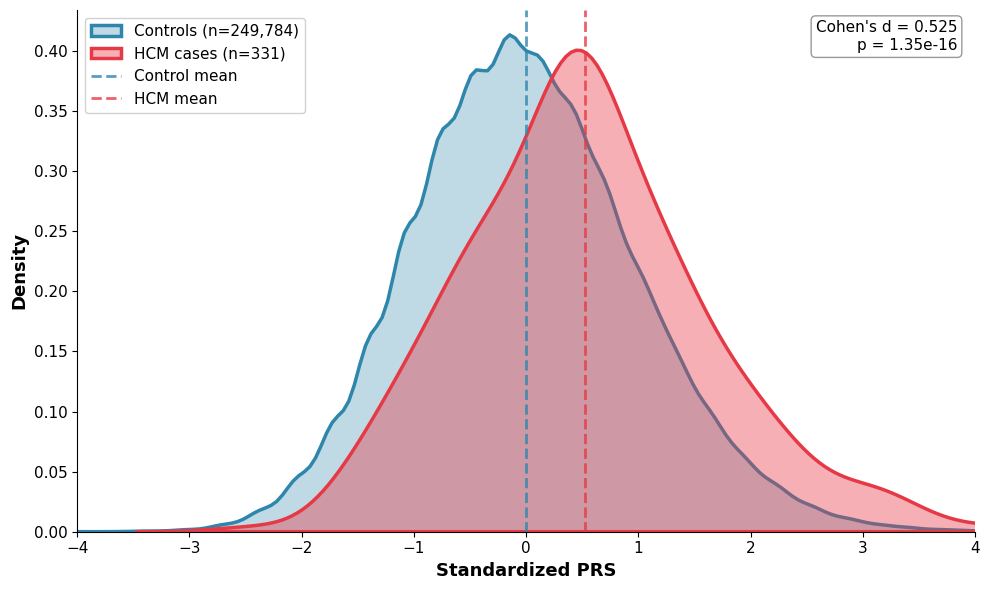

In [27]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate percentiles for HCM patients relative to controls
hcm_prs_scores['percentile'] = hcm_prs_scores['PRS'].apply(
    lambda x: stats.percentileofscore(control_prs_scores['PRS'], x)
)

# Summary statistics
print("PRS COMPARISON: HCM CASES VS CONTROLS")

print(f"\nControls (n={len(control_prs_scores):,}):")
print(f"  Raw PRS: {control_mean:.4f} ± {control_std:.4f}")
print(f"  Standardized: 0.0000 ± 1.0000")

hcm_mean_raw = hcm_prs_scores['PRS'].mean()
hcm_std_raw = hcm_prs_scores['PRS'].std()
hcm_mean_std = hcm_prs_scores['PRS_standardized'].mean()
hcm_std_std = hcm_prs_scores['PRS_standardized'].std()

print(f"\nHCM cases (n={len(hcm_prs_scores):,}):")
print(f"  Raw PRS: {hcm_mean_raw:.4f} ± {hcm_std_raw:.4f}")
print(f"  Standardized: {hcm_mean_std:.4f} ± {hcm_std_std:.4f}")

print(f"\nEffect size (Cohen's d): {hcm_mean_std:.4f}")

# Statistical test
t_stat, p_value = stats.ttest_ind(
    hcm_prs_scores['PRS'], 
    control_prs_scores['PRS'],
    equal_var=False  # Welch's t-test (more robust)
)
print(f"\nWelch's t-test:")
print(f"  t = {t_stat:.4f}")
print(f"  p = {p_value:.2e}")

# Percentile enrichment analysis
print(f"\nHCM enrichment in control PRS percentiles:")
for pct in [50, 75, 90, 95, 99]:
    threshold = np.percentile(control_prs_scores['PRS'], pct)
    n_above = (hcm_prs_scores['PRS'] > threshold).sum()
    pct_above = (n_above / len(hcm_prs_scores)) * 100
    expected = 100 - pct
    enrichment = pct_above / expected if expected > 0 else np.inf
    print(f"  >{pct}th: {n_above}/{len(hcm_prs_scores)} ({pct_above:.1f}%) [expected {expected}%, {enrichment:.2f}x]")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Density plots
sns.kdeplot(
    data=control_prs_scores['PRS_standardized'], 
    ax=ax, 
    color='#2E86AB',
    linewidth=2.5, 
    label=f'Controls (n={len(control_prs_scores):,})', 
    fill=True, 
    alpha=0.3
)

sns.kdeplot(
    data=hcm_prs_scores['PRS_standardized'], 
    ax=ax, 
    color='#E63946',
    linewidth=2.5, 
    label=f'HCM cases (n={len(hcm_prs_scores):,})', 
    fill=True, 
    alpha=0.4
)

# Mean lines
ax.axvline(0, color='#2E86AB', linestyle='--', linewidth=2, alpha=0.8, label='Control mean')
ax.axvline(hcm_mean_std, color='#E63946', linestyle='--', linewidth=2, alpha=0.8, label='HCM mean')

# Formatting
ax.set_xlabel('Standardized PRS', fontsize=13, fontweight='bold')
ax.set_ylabel('Density', fontsize=13, fontweight='bold')
ax.set_xlim(-4, 4)
ax.tick_params(labelsize=11)

# Legend and p-value
ax.legend(fontsize=11, loc='upper left', frameon=True, framealpha=0.9)
ax.text(
    0.98, 0.98, 
    f"Cohen's d = {hcm_mean_std:.3f}\np = {p_value:.2e}", 
    transform=ax.transAxes, 
    fontsize=11,
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
output_path = f"{OUTPUT_DIR}/prs_distribution_cases_vs_controls.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

# Pathogenic Variant Carrier Analysis

**Objective**: Identify carriers of pathogenic variants in HCM-associated genes and compare carrier frequencies between HCM cases and the full cohort.

## Approach

1. **Gene Panel**: 24 HCM-associated genes sourced from Invitae HCM panel with curated pathogenic variants from ClinVar
2. **Variant Extraction**: Extract genotype dosages from chromosome-specific PGEN files using PLINK2
3. **Dosage Inversion**: Convert PLINK ALT allele dosages to REF allele dosages (pathogenic alleles coded as REF)
4. **Carrier Classification**: Define carriers as individuals with dosage > 0 for any pathogenic variant
5. **Enrichment Analysis**: Calculate carrier frequency ratios (HCM cases vs. all samples)

## Outputs

### Per-Gene Files
- **Wide format**: One row per carrier with columns for each variant (`{GENE}_all_carriers_wide.tsv`, `{GENE}_hcm_carriers_wide.tsv`)
- **Includes**: Total dosage, number of variants carried, individual variant dosages

### Aggregated Files
- **Long format**: One row per person-variant combination (`all_carriers_long_format.tsv`, `hcm_carriers_long_format.tsv`)
- **Columns**: Gene, IID, variant_id, dosage, genotype (Het/Hom), HCM status
- **Summary table**: Gene-level carrier statistics and enrichment ratios (`summary_all_genes.tsv`)

## Key Metrics
- **Carrier prevalence** in all samples vs. HCM cohort
- **Enrichment ratio**: (% HCM carriers) / (% all carriers)
- **Variant coverage**: Number of input variants vs. variants found in genotype data

In [33]:
import pandas as pd
import subprocess
from pathlib import Path

# ==============================================================================
# CONFIGURATION
# ==============================================================================
OUTPUT_DIR = "/home/jupyter/prs_hcm_experiment/variant_counts"
GENE_CSV_DIR = "/home/jupyter/prs_hcm_experiment/gene_panel"
HCM_KEEP_FILE = '/home/jupyter/prs_hcm_experiment/prs/hcm_cohort.keep'

# Gene to chromosome mapping
GENE_CHROM_MAP = {
    'ACADVL': 17, 'ACTC1': 15, 'ACTN2': 1, 'MYH6': 14, 'AGL': 1,
    'CPT2': 1, 'ALPK3': 15, 'CACNA1C': 12, 'LAMP2': 23, 'MYL2': 12,
    'ELAC2': 17, 'FLNC': 7, 'MTO1': 6, 'TCAP': 17, 'MYH7': 14,
    'TPM1': 15, 'PRKAG2': 2, 'MYL3': 3, 'TNNI3': 19, 'TNNT2': 1,
    'TNNC1': 3, 'MYBPC3': 11, 'BRAF': 7, 'TBX1': 22
}

# ==============================================================================
# LOAD HCM COHORT
# ==============================================================================
hcm_ids = pd.read_csv(HCM_KEEP_FILE, sep=r'\s+', header=None, names=['IID', 'FID'])
hcm_iid_set = set(hcm_ids['IID'].astype(str))
print(f"Loaded {len(hcm_ids):,} HCM samples\n")

# ==============================================================================
# FIND GENE VARIANT FILES
# ==============================================================================
csv_files = sorted(Path(GENE_CSV_DIR).glob("*.csv"))
print(f"Found {len(csv_files)} gene variant CSV files\n")
print("="*80)

# ==============================================================================
# PROCESS EACH GENE
# ==============================================================================

summary_results = []
all_carriers_long = []
hcm_carriers_long = []

for csv_file in csv_files:
    gene_name = csv_file.stem.strip()
    
    if gene_name not in GENE_CHROM_MAP:
        print(f"WARNING: Skipping {gene_name} - not in gene-chromosome mapping")
        continue
    
    chrom = GENE_CHROM_MAP[gene_name]
    
    print(f"\nProcessing: {gene_name} (chr{chrom})")
    print("-" * 80)
    
    # --------------------------------------------------------------------------
    # Load variant list
    # --------------------------------------------------------------------------
    try:
        variants_df = pd.read_csv(csv_file, header=None)
        variant_ids = variants_df[0].dropna().astype(str).tolist()
        n_variants = len(variant_ids)
        print(f"  Loaded {n_variants} variant(s) from {csv_file.name}")
    except Exception as e:
        print(f"  ERROR reading {csv_file.name}: {e}")
        continue
    
    # --------------------------------------------------------------------------
    # Extract genotypes using PLINK2
    # --------------------------------------------------------------------------
    chrom_dir = f"{CHROM_BASE_PATH}/chrom-{chrom}/postproc-pgen"
    pfile_prefix = f"{chrom_dir}/dragen"
    output_prefix = f"{OUTPUT_DIR}/{gene_name}_dosages"
    
    cmd = [
        PLINK2_PATH,
        "--pfile", pfile_prefix,
        "--extract", str(csv_file),
        "--recode", "A",
        "--out", output_prefix
    ]
    
    print(f"  Extracting dosages from {pfile_prefix}...")
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode != 0:
        print(f"  ERROR: PLINK2 failed")
        print(f"  {result.stderr}")
        continue
    
    # Parse PLINK2 output for extracted variant count
    extracted_count = 0
    for line in result.stdout.split('\n'):
        if 'variants remaining' in line.lower() and 'after main filters' in line.lower():
            try:
                extracted_count = int(line.split()[0])
                break
            except:
                pass
    
    if extracted_count == 0:
        print(f"  WARNING: No variants found in PGEN file - skipping {gene_name}")
        continue
    
    print(f"  Extracted {extracted_count}/{n_variants} variants")
    
    # --------------------------------------------------------------------------
    # Load and process dosages
    # --------------------------------------------------------------------------
    dosage_file = f"{output_prefix}.raw"
    
    try:
        dosages = pd.read_csv(dosage_file, sep=r'\s+')
    except Exception as e:
        print(f"  ERROR loading dosage file: {e}")
        continue
    
    print(f"  Loaded dosages: {dosages.shape[0]:,} samples x {dosages.shape[1]} columns")
    
    # Identify variant columns
    standard_cols = ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE']
    variant_cols = [col for col in dosages.columns if col not in standard_cols]
    
    if len(variant_cols) == 0:
        print(f"  WARNING: No variant columns found - skipping {gene_name}")
        continue
    
    print(f"  Variants in dosage file: {len(variant_cols)}")
    
    # Invert dosages (ALT -> REF, since pathogenic alleles are coded as REF)
    for col in variant_cols:
        dosages[col] = 2 - dosages[col]
    
    # --------------------------------------------------------------------------
    # Calculate carrier status
    # --------------------------------------------------------------------------
    dosages['total_dosage'] = dosages[variant_cols].sum(axis=1)
    dosages['is_carrier'] = (dosages['total_dosage'] > 0).astype(int)
    dosages['num_variants'] = (dosages[variant_cols] > 0).sum(axis=1)
    
    # Label HCM samples
    dosages['IID'] = dosages['IID'].astype(str)
    dosages['is_hcm'] = dosages['IID'].isin(hcm_iid_set).astype(int)
    
    # --------------------------------------------------------------------------
    # Calculate statistics
    # --------------------------------------------------------------------------
    all_samples = dosages
    hcm_samples = dosages[dosages['is_hcm'] == 1]
    
    n_all_carriers = all_samples['is_carrier'].sum()
    pct_all = (n_all_carriers / len(all_samples)) * 100
    
    n_hcm = len(hcm_samples)
    n_hcm_carriers = hcm_samples['is_carrier'].sum()
    pct_hcm = (n_hcm_carriers / n_hcm) * 100 if n_hcm > 0 else 0
    
    enrichment = pct_hcm / pct_all if pct_all > 0 else 0
    
    # Print results
    print(f"\n  RESULTS:")
    print(f"    All samples (n={len(all_samples):,}): {n_all_carriers:,} carriers ({pct_all:.4f}%)")
    print(f"    HCM cohort (n={n_hcm:,}): {n_hcm_carriers:,} carriers ({pct_hcm:.2f}%)")
    if enrichment > 0:
        print(f"    Enrichment: {enrichment:.2f}x")
    
    # --------------------------------------------------------------------------
    # Save wide-format carrier files
    # --------------------------------------------------------------------------
    carrier_cols = ['FID', 'IID', 'total_dosage', 'num_variants']
    
    all_carriers_wide = all_samples[all_samples['is_carrier'] == 1][
        carrier_cols + ['is_hcm'] + variant_cols
    ]
    hcm_carriers_wide = hcm_samples[hcm_samples['is_carrier'] == 1][
        carrier_cols + variant_cols
    ]
    
    all_carriers_wide.to_csv(
        f"{OUTPUT_DIR}/{gene_name}_all_carriers_wide.tsv", 
        sep='\t', 
        index=False
    )
    hcm_carriers_wide.to_csv(
        f"{OUTPUT_DIR}/{gene_name}_hcm_carriers_wide.tsv", 
        sep='\t', 
        index=False
    )
    
    # --------------------------------------------------------------------------
    # Build long-format records
    # --------------------------------------------------------------------------
    # All carriers
    for _, row in all_samples[all_samples['is_carrier'] == 1].iterrows():
        for var_col in variant_cols:
            dosage_val = row[var_col]
            if dosage_val > 0:
                all_carriers_long.append({
                    'Gene': gene_name,
                    'IID': row['IID'],
                    'FID': row['FID'],
                    'is_hcm': row['is_hcm'],
                    'variant_id': var_col.replace('_', ':'),
                    'dosage': int(dosage_val),
                    'genotype': 'Het' if dosage_val == 1 else 'Hom'
                })
    
    # HCM carriers
    for _, row in hcm_samples[hcm_samples['is_carrier'] == 1].iterrows():
        for var_col in variant_cols:
            dosage_val = row[var_col]
            if dosage_val > 0:
                hcm_carriers_long.append({
                    'Gene': gene_name,
                    'IID': row['IID'],
                    'FID': row['FID'],
                    'variant_id': var_col.replace('_', ':'),
                    'dosage': int(dosage_val),
                    'genotype': 'Het' if dosage_val == 1 else 'Hom'
                })
    
    # --------------------------------------------------------------------------
    # Store summary
    # --------------------------------------------------------------------------
    summary_results.append({
        'Gene': gene_name,
        'Chromosome': chrom,
        'Variants_Input': n_variants,
        'Variants_Found': extracted_count,
        'All_N': len(all_samples),
        'All_Carriers': n_all_carriers,
        'All_Carrier_Pct': pct_all,
        'HCM_N': n_hcm,
        'HCM_Carriers': n_hcm_carriers,
        'HCM_Carrier_Pct': pct_hcm,
        'Enrichment': enrichment
    })

# ==============================================================================
# SAVE SUMMARY AND LONG-FORMAT FILES
# ==============================================================================

summary_output = f"{OUTPUT_DIR}/summary_all_genes.tsv"
summary_df.to_csv(summary_output, sep='\t', index=False)

# Save long-format files
if all_carriers_long:
    all_long_df = pd.DataFrame(all_carriers_long)
    all_long_df = all_long_df.sort_values(['IID', 'Gene', 'variant_id'])
    all_long_output = f"{OUTPUT_DIR}/all_carriers_long_format.tsv"
    all_long_df.to_csv(all_long_output, sep='\t', index=False)
    
    print(f"\nALL COHORT (long format):")
    print(f"  {len(all_long_df):,} person-variant records")
    print(f"  {all_long_df['IID'].nunique():,} unique carriers")

if hcm_carriers_long:
    hcm_long_df = pd.DataFrame(hcm_carriers_long)
    hcm_long_df = hcm_long_df.sort_values(['IID', 'Gene', 'variant_id'])
    hcm_long_output = f"{OUTPUT_DIR}/hcm_carriers_long_format.tsv"
    hcm_long_df.to_csv(hcm_long_output, sep='\t', index=False)
    
    print(f"\nHCM COHORT (long format):")
    print(f"  {len(hcm_long_df):,} person-variant records")
    print(f"  {hcm_long_df['IID'].nunique():,} unique HCM carriers")

Loaded 331 HCM samples

Found 24 gene variant CSV files


Processing: ACADVL (chr17)
--------------------------------------------------------------------------------
  Loaded 47 variant(s) from  ACADVL.csv
  Extracting dosages from /home/jupyter/gcs/chrom-17/postproc-pgen/dragen...
  Extracted 16/47 variants
  Loaded dosages: 250,115 samples x 22 columns
  Variants in dosage file: 16

  RESULTS:
    All samples (n=250,115): 233 carriers (0.0932%)
    HCM cohort (n=331): 0 carriers (0.00%)

Processing: ACTC1 (chr15)
--------------------------------------------------------------------------------
  Loaded 2 variant(s) from ACTC1.csv
  Extracting dosages from /home/jupyter/gcs/chrom-15/postproc-pgen/dragen...

Processing: ACTN2 (chr1)
--------------------------------------------------------------------------------
  Loaded 2 variant(s) from ACTN2.csv
  Extracting dosages from /home/jupyter/gcs/chrom-1/postproc-pgen/dragen...
  ERROR: PLINK2 failed
  Error: No variants remaining after main

## Four-Group PRS Distribution Analysis

To better understand the interplay between **genetic variants** (pathogenic variant carrier status) and **polygenic background** (PRS), we stratified our cohorts into four distinct groups:

1. **Gen Pop Non-Carriers**: Individuals without HCM and without pathogenic variants
2. **Gen Pop Carriers**: Individuals without HCM but carrying pathogenic variants
3. **HCM Non-Carriers**: HCM patients without identifiable pathogenic variants
4. **HCM Carriers**: HCM patients carrying pathogenic variants

This stratification allows us to:
- Assess whether PRS differs between carriers and non-carriers within each cohort
- Evaluate whether HCM patients have elevated PRS regardless of carrier status
- Test the **polygenic modifier hypothesis**: Does PRS influence disease expression in carriers?

### Key Analyses:
- **Density plots**: Visual comparison of PRS distributions across all four groups
- **Violin plots**: Distribution shape, spread, and statistical significance testing
- **Pairwise comparisons**: Mann-Whitney U tests for each group combination
- **Summary statistics**: Mean, median, quartiles, and sample sizes

### Clinical Implications:
Understanding PRS differences between these groups may help explain:
- **Incomplete penetrance** in variant carriers without disease
- **Phenotypic heterogeneity** among HCM patients
- **Polygenic contributions** to disease risk beyond monogenic variants


Total unique carriers: 1558
  HCM carriers: 46
  Gen Pop carriers: 1512

=== FOUR-GROUP ANALYSIS ===

Group sizes:
  Gen Pop Non-Carriers: 248262
  Gen Pop Carriers: 1512
  HCM Non-Carriers: 285
  HCM Carriers: 46

=== SUMMARY STATISTICS ===
                           N    Mean  Median     Std     Min     Max     Q25  \
Group                                                                          
Gen Pop Carriers        1512 -4.0380 -4.0623  0.6412 -5.8666 -1.6635 -4.4914   
Gen Pop Non-Carriers  248262 -4.0425 -4.0709  0.6338 -6.6096 -0.6894 -4.4832   
HCM Carriers              46 -3.6669 -3.6625  0.6887 -4.9949 -2.0315 -4.1511   
HCM Non-Carriers         285 -3.7166 -3.7751  0.6953 -5.5899 -1.0817 -4.2095   

                         Q75  
Group                         
Gen Pop Carriers     -3.6192  
Gen Pop Non-Carriers -3.6345  
HCM Carriers         -3.2987  
HCM Non-Carriers     -3.2781  

=== OVERALL TEST ===
Kruskal-Wallis H-test: H=75.2520, p=3.1996e-16

=== PAIRWISE COMPARI

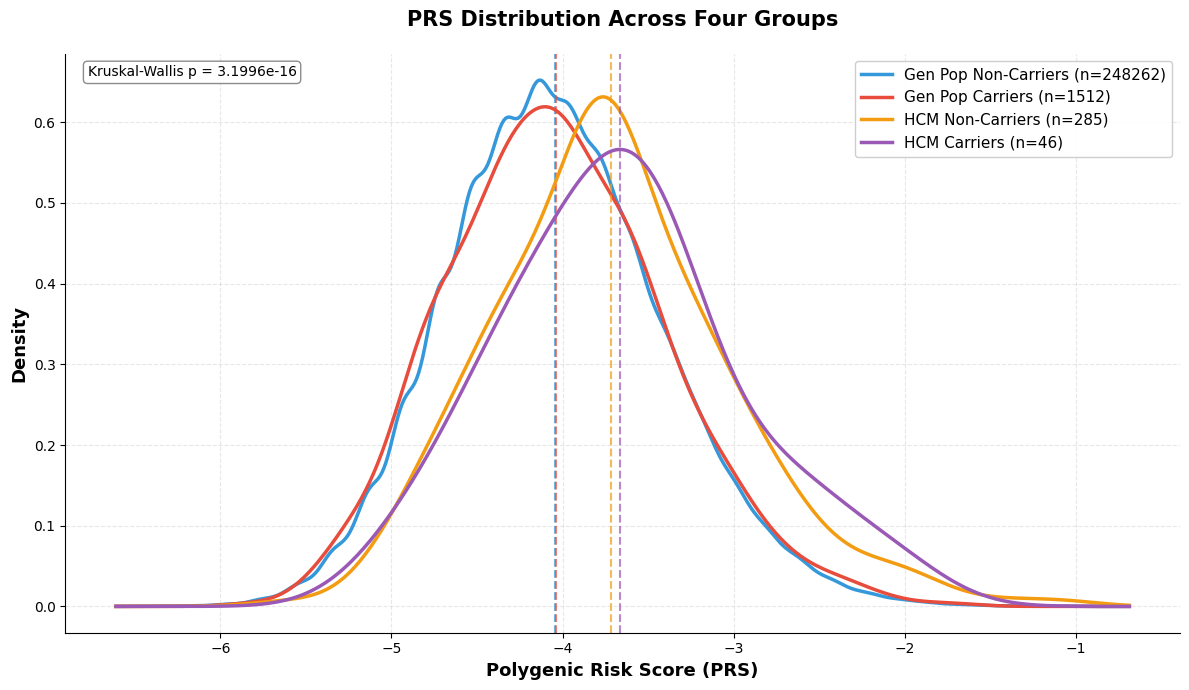

In [43]:
from scipy.stats import mannwhitneyu, kruskal, gaussian_kde

prs_file = "/home/jupyter/prs_hcm_experiment/prs/prs_scores_all_samples.tsv"

# Load PRS data
hcm_prs_file = "/home/jupyter/prs_hcm_experiment/prs/prs_scores_hcm_cohort.tsv"
all_prs_file = "/home/jupyter/prs_hcm_experiment/prs/prs_scores_all_samples.tsv"

hcm_prs_df = pd.read_csv(hcm_prs_file, sep='\t')
all_prs_df = pd.read_csv(all_prs_file, sep='\t')

# Filter out reference samples from all_prs
all_prs_df = all_prs_df[~all_prs_df['IID'].str.contains('_PrecFDA|_DeCODE', na=False)]

# Get HCM IIDs
hcm_iids = set(hcm_prs_df['IID'])

# Gen Pop = samples in all_prs but NOT in HCM
genpop_prs_df = all_prs_df[~all_prs_df['IID'].isin(hcm_iids)].copy()

# Load carrier status
carriers_file = "/home/jupyter/prs_hcm_experiment/variant_counts/all_carriers_long_format.tsv"
carriers_df = pd.read_csv(carriers_file, sep='\t')

# Get unique carriers with their HCM status
unique_carriers = carriers_df[['IID', 'is_hcm']].drop_duplicates()
print(f"\nTotal unique carriers: {len(unique_carriers)}")
print(f"  HCM carriers: {(unique_carriers['is_hcm'] == 1).sum()}")
print(f"  Gen Pop carriers: {(unique_carriers['is_hcm'] == 0).sum()}")

# Merge PRS with carrier status
carriers_with_prs = unique_carriers.merge(prs_df, on='IID', how='inner')

# Create four groups
# Group 1: Gen Pop Non-Carriers (all Gen Pop samples minus Gen Pop carriers)
genpop_carrier_iids = unique_carriers[unique_carriers['is_hcm'] == 0]['IID']
genpop_noncarriers = genpop_prs_df[~genpop_prs_df['IID'].isin(genpop_carrier_iids)].copy()

# Group 2: Gen Pop Carriers
genpop_carriers = genpop_prs_df[genpop_prs_df['IID'].isin(genpop_carrier_iids)].copy()

# Group 3: HCM Non-Carriers (all HCM samples minus HCM carriers)
hcm_carrier_iids = unique_carriers[unique_carriers['is_hcm'] == 1]['IID']
hcm_noncarriers = hcm_prs_df[~hcm_prs_df['IID'].isin(hcm_carrier_iids)].copy()

# Group 4: HCM Carriers
hcm_carriers = hcm_prs_df[hcm_prs_df['IID'].isin(hcm_carrier_iids)].copy()
# Create combined dataframe
prs_data_4group = pd.concat([
    pd.DataFrame({'IID': genpop_noncarriers['IID'], 
                  'PRS': genpop_noncarriers['PRS'],
                  'Group': 'Gen Pop\nNon-Carriers'}),
    pd.DataFrame({'IID': genpop_carriers['IID'], 
                  'PRS': genpop_carriers['PRS'],
                  'Group': 'Gen Pop\nCarriers'}),
    pd.DataFrame({'IID': hcm_noncarriers['IID'], 
                  'PRS': hcm_noncarriers['PRS'],
                  'Group': 'HCM\nNon-Carriers'}),
    pd.DataFrame({'IID': hcm_carriers['IID'], 
                  'PRS': hcm_carriers['PRS'],
                  'Group': 'HCM\nCarriers'})
], ignore_index=True)

prs_data_4group['Group'] = prs_data_4group['Group'].str.replace(r'\\n', ' ', regex=True)
prs_data_4group['Group'] = prs_data_4group['Group'].str.replace(r'\n', ' ', regex=True)
prs_data_4group['Group'] = prs_data_4group['Group'].str.strip()  # Remove leading/trailing spaces

print("\n=== FOUR-GROUP ANALYSIS ===")
print(f"\nGroup sizes:")
for group in ['Gen Pop Non-Carriers', 'Gen Pop Carriers', 'HCM Non-Carriers', 'HCM Carriers']:
    n = len(prs_data_4group[prs_data_4group['Group'] == group])
    print(f"  {group.replace(chr(10), ' ')}: {n}")

# Calculate summary statistics
groups_4 = ['Gen Pop Non-Carriers', 'Gen Pop Carriers', 'HCM Non-Carriers', 'HCM Carriers']

print("\n=== SUMMARY STATISTICS ===")
stats_4group = prs_data_4group.groupby('Group')['PRS'].agg([
    ('N', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Q25', lambda x: np.percentile(x, 25)),
    ('Q75', lambda x: np.percentile(x, 75))
]).round(4)
print(stats_4group)

# Kruskal-Wallis test
group_arrays_4 = [prs_data_4group[prs_data_4group['Group'] == g]['PRS'].values for g in groups_4]
h_stat_4, p_kruskal_4 = kruskal(*group_arrays_4)
print(f"\n=== OVERALL TEST ===")
print(f"Kruskal-Wallis H-test: H={h_stat_4:.4f}, p={p_kruskal_4:.4e}")

# Pairwise Mann-Whitney U tests
print("\n=== PAIRWISE COMPARISONS ===")
pairwise_results = []
for i in range(len(groups_4)):
    for j in range(i+1, len(groups_4)):
        group1 = groups_4[i]
        group2 = groups_4[j]
        
        prs1 = prs_data_4group[prs_data_4group['Group'] == group1]['PRS'].values
        prs2 = prs_data_4group[prs_data_4group['Group'] == group2]['PRS'].values
        
        statistic, pvalue = mannwhitneyu(prs1, prs2, alternative='two-sided')
        
        pairwise_results.append({
            'Group 1': group1.replace('\n', ' '),
            'Group 2': group2.replace('\n', ' '),
            'N1': len(prs1),
            'N2': len(prs2),
            'Mean1': np.mean(prs1),
            'Mean2': np.mean(prs2),
            'U-statistic': statistic,
            'p-value': pvalue,
            'Significant': '***' if pvalue < 0.001 else '**' if pvalue < 0.01 else '*' if pvalue < 0.05 else 'ns'
        })

pairwise_4group = pd.DataFrame(pairwise_results)
print(pairwise_4group.to_string(index=False))

# PLOT 1: Four-group density plot
fig, ax = plt.subplots(figsize=(12, 7))

colors_4 = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6']
group_labels = ['Gen Pop Non-Carriers', 'Gen Pop Carriers', 'HCM Non-Carriers', 'HCM Carriers']

for group, color, label in zip(groups_4, colors_4, group_labels):
    data = prs_data_4group[prs_data_4group['Group'] == group]['PRS']
    n = len(data)
    
    # Plot KDE
    kde = gaussian_kde(data)
    x_range = np.linspace(prs_data_4group['PRS'].min(), prs_data_4group['PRS'].max(), 500)
    density = kde(x_range)
    
    ax.plot(x_range, density, color=color, linewidth=2.5, label=f'{label} (n={n})')
    
    # Add mean line
    mean_val = data.mean()
    ax.axvline(mean_val, color=color, linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Polygenic Risk Score (PRS)', fontsize=13, fontweight='bold')
ax.set_ylabel('Density', fontsize=13, fontweight='bold')
ax.set_title('PRS Distribution Across Four Groups', fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=11, framealpha=0.95)
ax.grid(alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add statistics annotation
stats_text = f"Kruskal-Wallis p = {p_kruskal_4:.4e}"
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()
plt.savefig('/home/jupyter/prs_hcm_experiment/plots/prs_4group_density.png', dpi=300, bbox_inches='tight')
plt.show()

# Save statistics
stats_4group.to_csv('/home/jupyter/prs_hcm_experiment/prs/prs_4group_summary_stats.tsv', sep='\t')
pairwise_4group.to_csv('/home/jupyter/prs_hcm_experiment/prs/prs_4group_pairwise_tests.tsv', sep='\t', index=False)

/var/tmp/ipykernel_1833523/3918049672.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=prs_data_4group, x='Group', y='PRS', order=order,
/var/tmp/ipykernel_1833523/3918049672.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')


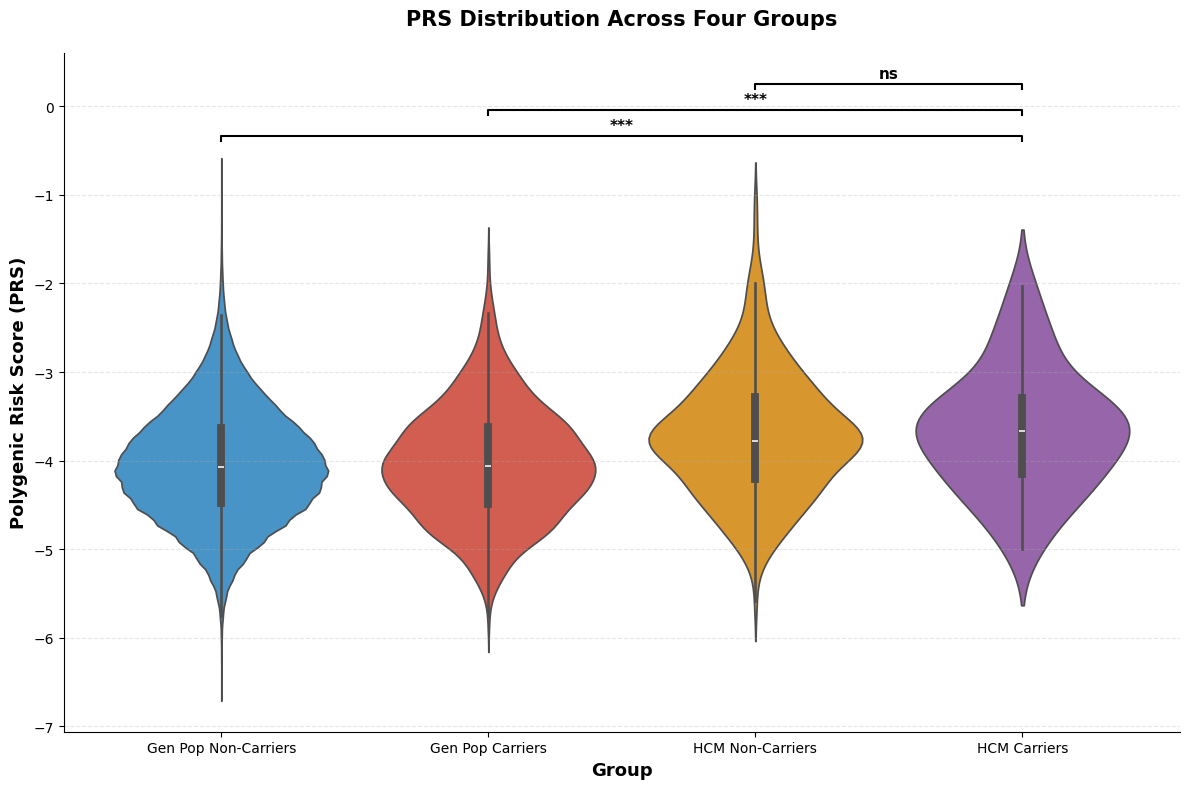

In [46]:
# PLOT 2: Violin plot with annotations

fig, ax = plt.subplots(figsize=(12, 8))

# Define order for plotting
order = ['Gen Pop Non-Carriers', 'Gen Pop Carriers', 'HCM Non-Carriers', 'HCM Carriers']

# Create violin plot
sns.violinplot(data=prs_data_4group, x='Group', y='PRS', order=order,
               palette=['#3498db', '#e74c3c', '#f39c12', '#9b59b6'],
               inner='box', ax=ax)

ax.set_xlabel('Group', fontsize=13, fontweight='bold')
ax.set_ylabel('Polygenic Risk Score (PRS)', fontsize=13, fontweight='bold')
ax.set_title('PRS Distribution Across Four Groups', fontsize=15, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Manual significance annotations
# Define pairs to compare and their significance
pairs = [
    ('Gen Pop Non-Carriers', 'Gen Pop Carriers'),
    ('Gen Pop Non-Carriers', 'HCM Non-Carriers'),
    ('Gen Pop Non-Carriers', 'HCM Carriers'),
    ('Gen Pop Carriers', 'HCM Non-Carriers'),
    ('Gen Pop Carriers', 'HCM Carriers'),
    ('HCM Non-Carriers', 'HCM Carriers')
]

# Get p-values from pairwise_4group
sig_dict = {}
for _, row in pairwise_4group.iterrows():
    key = (row['Group 1'], row['Group 2'])
    sig_dict[key] = row['Significant']

# Position for brackets (y-coordinates)
y_max = prs_data_4group['PRS'].max()
y_min = prs_data_4group['PRS'].min()
y_range = y_max - y_min
h = y_range * 0.05  # Height increment for brackets

selected_pairs = [
    ('Gen Pop Non-Carriers', 'HCM Carriers', 0),
    ('Gen Pop Carriers', 'HCM Carriers', 1),
    ('HCM Non-Carriers', 'HCM Carriers', 2),
]

# Map groups to x positions
x_positions = {group: i for i, group in enumerate(order)}

for (g1, g2, level) in selected_pairs:
    sig = sig_dict.get((g1, g2), sig_dict.get((g2, g1), 'ns'))
    
    x1 = x_positions[g1]
    x2 = x_positions[g2]
    
    # Calculate bracket position
    y = y_max + h * (level + 1)
    
    # Draw bracket
    ax.plot([x1, x1, x2, x2], [y, y + h*0.2, y + h*0.2, y], 
            lw=1.5, c='black')
    
    # Add significance text
    ax.text((x1 + x2) / 2, y + h*0.3, sig, ha='center', va='bottom', 
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/jupyter/prs_hcm_experiment/plots/prs_4group_violin.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Clinical Phenotype Enrichment and Risk Stratification

Having established that **polygenic risk scores (PRS)** differ across carrier status and disease cohorts, we now investigate the **clinical consequences** of carrying pathogenic variants. This section explores:

1. **Cardiovascular phenotype burden** in variant carriers
2. **Gene-specific disease associations** 
3. **Age-dependent disease expression** (penetrance over time)
4. **Quantitative risk metrics** (odds ratios, relative risk)
5. **PRS-stratified penetrance** (interaction between monogenic and polygenic risk)

---

## Cardiovascular Condition Enrichment in Variant Carriers

We first assess whether carrying a pathogenic variant is associated with increased rates of cardiovascular (CV) conditions, comparing:
- **Gen Pop Carriers vs. Gen Pop Non-Carriers** (baseline pathogenicity)
- **HCM Carriers vs. HCM Non-Carriers** (disease-specific associations)

### Objectives:
- Identify which CV conditions are significantly enriched in carriers
- Quantify effect sizes using odds ratios and Fisher's exact tests
- Compare enrichment patterns between HCM and Gen Pop cohorts

### Expected Findings:
- Carriers may show elevated rates of specific cardiovascular conditions
- Gene-specific enrichment patterns may emerge (e.g., *MYH7* vs. *MYBPC3*)

In [56]:
from google.cloud import bigquery

client = bigquery.Client()
OMOP_DATASET = "nb-tre-dev-2-483522.omop_dataset_v2026_1_1"

In [57]:
# GENE-STRATIFIED CV ENRICHMENT ANALYSIS
print("GENE-STRATIFIED CARDIOVASCULAR CONDITION ENRICHMENT ANALYSIS")

print("\n Loading carrier and cohort data...")

# Load all genotyped individuals
CHROM_BASE_PATH = "/home/jupyter/gcs/chrom-1/postproc-pgen"
psam_file = f"{CHROM_BASE_PATH}/dragen.psam"

print(f"   Loading genotyped individuals from: {psam_file}")
psam_df = pd.read_csv(psam_file, sep='\t')

# Handle both #IID and IID column names
if '#IID' in psam_df.columns:
    genotyped_all_iids = set(psam_df['#IID'].astype(str))
elif 'IID' in psam_df.columns:
    genotyped_all_iids = set(psam_df['IID'].astype(str))
else:
    print("   Available columns:", list(psam_df.columns))
    raise ValueError("Cannot find IID column in .psam file")

# Load all carriers
carriers_file = "/home/jupyter/prs_hcm_experiment/variant_counts/all_carriers_long_format.tsv"
all_carriers_long = pd.read_csv(carriers_file, sep='\t')
print(f"   Carriers identified across {all_carriers_long['Gene'].nunique()} genes")

# Load HCM cohort
hcm_cohort_file = "/home/jupyter/prs_output/hcm_cohort.keep"
hcm_cohort = pd.read_csv(hcm_cohort_file, sep='\t', header=None, names=['FID', 'IID'])
hcm_all_iids = set(hcm_cohort['IID'].astype(str))

# Separate carriers by HCM status
hcm_carrier_iids = set(all_carriers_long[all_carriers_long['is_hcm'] == 1]['IID'].astype(str).unique())
genpop_carrier_iids = set(all_carriers_long[all_carriers_long['is_hcm'] == 0]['IID'].astype(str).unique())

# Define non-carriers
hcm_noncarrier_iids = hcm_all_iids - hcm_carrier_iids
genpop_all_iids = genotyped_all_iids - hcm_all_iids
genpop_noncarrier_iids = genpop_all_iids - genpop_carrier_iids

# ============================================================================
# QUERY FUNCTION
# ============================================================================

def get_cv_conditions(iid_set, label, exclude_hcm_codes=False):
    """
    Query CV conditions for a set of person IDs
    
    Args:
        iid_set: Set of individual IDs
        label: Description for logging
        exclude_hcm_codes: If True, exclude HCM-specific ICD codes
    """
    if len(iid_set) == 0:
        print(f"   WARNING: Empty IID set for {label}")
        return pd.DataFrame()
    
    iid_list = list(iid_set)
    batch_size = 10000
    
    # Build HCM exclusion clause
    if exclude_hcm_codes:
        hcm_exclusion = """
            AND co.condition_source_value NOT IN ('I42.1', 'I42.2', '425.1', '425.11', '425.18')
            AND co.condition_source_value NOT LIKE 'I42.1%'
            AND co.condition_source_value NOT LIKE 'I42.2%'
        """
    else:
        hcm_exclusion = ""
    
    # Handle large cohorts with batching
    if len(iid_list) > batch_size:
        print(f"   Querying {label} ({len(iid_list):,} individuals, batching)...")
        all_results = []
        
        for i in range(0, len(iid_list), batch_size):
            batch = iid_list[i:i+batch_size]
            batch_str = "', '".join(batch)
            
            query = f"""
            WITH target_people AS (
                SELECT person_id
                FROM `{OMOP_DATASET}.person`
                WHERE person_id IN ('{batch_str}')
            ),
            cv_conditions AS (
                SELECT 
                    co.person_id,
                    co.condition_source_value,
                    co.condition_start_date,
                    c.concept_name AS condition_name,
                    p.birth_datetime,
                    DATE_DIFF(co.condition_start_date, DATE(p.birth_datetime), YEAR) AS age_at_dx
                FROM `{OMOP_DATASET}.condition_occurrence` co
                INNER JOIN `{OMOP_DATASET}.person` p ON co.person_id = p.person_id
                LEFT JOIN `{OMOP_DATASET}.concept` c ON co.condition_concept_id = c.concept_id
                WHERE (
                    co.condition_source_value LIKE 'I%%'
                    OR (co.condition_source_value >= '390' AND co.condition_source_value < '460')
                )
                {hcm_exclusion}
                AND co.person_id IN (SELECT person_id FROM target_people)
            )
            SELECT * FROM cv_conditions
            """
            
            batch_df = client.query(query).to_dataframe()
            all_results.append(batch_df)
            print(f"      Batch {i//batch_size + 1}/{(len(iid_list)-1)//batch_size + 1} complete")
        
        df = pd.concat(all_results, ignore_index=True)
    else:
        iid_str = "', '".join(iid_list)
        
        query = f"""
        WITH target_people AS (
            SELECT person_id
            FROM `{OMOP_DATASET}.person`
            WHERE person_id IN ('{iid_str}')
        ),
        cv_conditions AS (
            SELECT 
                co.person_id,
                co.condition_source_value,
                co.condition_start_date,
                c.concept_name AS condition_name,
                p.birth_datetime,
                DATE_DIFF(co.condition_start_date, DATE(p.birth_datetime), YEAR) AS age_at_dx
            FROM `{OMOP_DATASET}.condition_occurrence` co
            INNER JOIN `{OMOP_DATASET}.person` p ON co.person_id = p.person_id
            LEFT JOIN `{OMOP_DATASET}.concept` c ON co.condition_concept_id = c.concept_id
            WHERE (
                co.condition_source_value LIKE 'I%%'
                OR (co.condition_source_value >= '390' AND co.condition_source_value < '460')
            )
            {hcm_exclusion}
            AND co.person_id IN (SELECT person_id FROM target_people)
        )
        SELECT * FROM cv_conditions
        ORDER BY person_id, condition_start_date
        """
        
        print(f"   Querying {label}...")
        df = client.query(query).to_dataframe()
    
    n_individuals = df['person_id'].nunique() if len(df) > 0 else 0
    print(f"   Found {len(df):,} CV records for {n_individuals:,} individuals")
    
    return df

# ============================================================================
# ENRICHMENT ANALYSIS FUNCTION
# ============================================================================

def calculate_gene_enrichment(gene, carrier_iids, noncarrier_iids, cohort_name, exclude_hcm_codes=False):
    """Calculate CV condition enrichment for a specific gene"""
    
    print(f"\n{'-'*80}")
    print(f"GENE: {gene} | COHORT: {cohort_name}")
    print(f"{'-'*80}")
    
    carrier_iids = set(str(x) for x in carrier_iids)
    noncarrier_iids = set(str(x) for x in noncarrier_iids)
    
    print(f"   Carriers: {len(carrier_iids):,}")
    print(f"   Non-carriers: {len(noncarrier_iids):,}")
    
    # Get CV conditions
    carrier_cv = get_cv_conditions(carrier_iids, f"{gene} carriers", exclude_hcm_codes)
    noncarrier_cv = get_cv_conditions(noncarrier_iids, f"{cohort_name} non-carriers", exclude_hcm_codes)
    
    # Overall prevalence
    carriers_with_cv = carrier_cv['person_id'].nunique() if len(carrier_cv) > 0 else 0
    noncarriers_with_cv = noncarrier_cv['person_id'].nunique() if len(noncarrier_cv) > 0 else 0
    
    carrier_rate = carriers_with_cv / len(carrier_iids) if len(carrier_iids) > 0 else 0
    noncarrier_rate = noncarriers_with_cv / len(noncarrier_iids) if len(noncarrier_iids) > 0 else 0
    
    print(f"\n   Overall CV Prevalence:")
    print(f"      Carriers: {carriers_with_cv}/{len(carrier_iids)} ({carrier_rate*100:.1f}%)")
    print(f"      Non-carriers: {noncarriers_with_cv}/{len(noncarrier_iids)} ({noncarrier_rate*100:.1f}%)")
    
    # Fisher's exact test
    if len(carrier_iids) > 0 and len(noncarrier_iids) > 0:
        contingency_table = [
            [carriers_with_cv, len(carrier_iids) - carriers_with_cv],
            [noncarriers_with_cv, len(noncarrier_iids) - noncarriers_with_cv]
        ]
        odds_ratio, pvalue = stats.fisher_exact(contingency_table)
        print(f"      OR = {odds_ratio:.2f}, p = {pvalue:.2e}")
    else:
        odds_ratio, pvalue = np.nan, np.nan
    
    # Condition-specific enrichment
    if len(carrier_cv) == 0 or len(noncarrier_cv) == 0:
        print("   Insufficient data for condition-specific analysis")
        return pd.DataFrame()
    
    # Group by ICD prefix
    carrier_cv['icd_prefix'] = carrier_cv['condition_source_value'].str[:3]
    noncarrier_cv['icd_prefix'] = noncarrier_cv['condition_source_value'].str[:3]
    
    carrier_condition_counts = carrier_cv.groupby('icd_prefix')['person_id'].nunique().reset_index()
    carrier_condition_counts.columns = ['icd_prefix', 'carrier_count']
    
    noncarrier_condition_counts = noncarrier_cv.groupby('icd_prefix')['person_id'].nunique().reset_index()
    noncarrier_condition_counts.columns = ['icd_prefix', 'noncarrier_count']
    
    condition_comparison = carrier_condition_counts.merge(
        noncarrier_condition_counts, on='icd_prefix', how='outer'
    ).fillna(0)

    # Consolidate cardiomyopathy rows
    cm_rows = condition_comparison[condition_comparison['icd_prefix'].isin(['I42', '425', 'I43'])]

    if len(cm_rows) > 0:
        # Get unique persons from original data - FIXED VARIABLE NAMES
        cm_carrier_persons = carrier_cv[
            carrier_cv['icd_prefix'].isin(['I42', '425', 'I43'])
        ]['person_id'].nunique()
    
        cm_noncarrier_persons = noncarrier_cv[
            noncarrier_cv['icd_prefix'].isin(['I42', '425', 'I43'])
        ]['person_id'].nunique()
    
        # Calculate statistics - FIXED TO USE len(carrier_iids)
        table = [[cm_carrier_persons, len(carrier_iids) - cm_carrier_persons],
                 [cm_noncarrier_persons, len(noncarrier_iids) - cm_noncarrier_persons]]
        odds, p = stats.fisher_exact(table)
    
        # Remove fragmented rows
        condition_comparison = condition_comparison[
            ~condition_comparison['icd_prefix'].isin(['I42', '425', 'I43'])
        ]
    
        # Add single consolidated row - FIXED RATE CALCULATIONS
        cm_row = pd.DataFrame([{
            'icd_prefix': 'CM_ALL',
            'condition_name': 'Cardiomyopathy (non-HCM)',
            'carrier_count': cm_carrier_persons,
            'noncarrier_count': cm_noncarrier_persons,
            'carrier_rate': cm_carrier_persons / len(carrier_iids),
            'noncarrier_rate': cm_noncarrier_persons / len(noncarrier_iids),
            'fold_enrichment': (cm_carrier_persons / len(carrier_iids)) / (cm_noncarrier_persons / len(noncarrier_iids)) if cm_noncarrier_persons > 0 else np.inf,
            'odds_ratio': odds,
            'pvalue': p,
            'significant': p < 0.05,
            'display_name': 'Cardiomyopathy (non-HCM)'
        }])
    
        condition_comparison = pd.concat([condition_comparison, cm_row], ignore_index=True)
    
    # Get representative condition names
    all_cv = pd.concat([carrier_cv, noncarrier_cv])
    
    def get_condition_name(icd_prefix):
        subset = all_cv[all_cv['icd_prefix'] == icd_prefix]
        if len(subset) == 0 or subset['condition_name'].isna().all():
            return icd_prefix
        mode_series = subset['condition_name'].mode()
        return mode_series[0] if len(mode_series) > 0 else icd_prefix
    
    condition_comparison['condition_name'] = condition_comparison['icd_prefix'].apply(get_condition_name)
    
    # Calculate rates and enrichment
    condition_comparison['carrier_rate'] = condition_comparison['carrier_count'] / len(carrier_iids)
    condition_comparison['noncarrier_rate'] = condition_comparison['noncarrier_count'] / len(noncarrier_iids)
    condition_comparison['fold_enrichment'] = (
        condition_comparison['carrier_rate'] / 
        condition_comparison['noncarrier_rate'].replace(0, np.nan)
    )
    
    # Fisher's exact test for each condition
    def calculate_fisher_pvalue(row):
        table = [
            [row['carrier_count'], len(carrier_iids) - row['carrier_count']],
            [row['noncarrier_count'], len(noncarrier_iids) - row['noncarrier_count']]
        ]
        odds_r, p = stats.fisher_exact(table)
        return p
    
    condition_comparison['pvalue'] = condition_comparison.apply(calculate_fisher_pvalue, axis=1)
    condition_comparison = condition_comparison.sort_values('fold_enrichment', ascending=False)
    
    # Add metadata
    condition_comparison['gene'] = gene
    condition_comparison['cohort'] = cohort_name
    condition_comparison['n_carriers'] = len(carrier_iids)
    condition_comparison['n_noncarriers'] = len(noncarrier_iids)
    condition_comparison['overall_OR'] = odds_ratio
    condition_comparison['overall_pvalue'] = pvalue
    
    # Display top enriched conditions
    print(f"\n   Top 10 Enriched Conditions:")
    display_df = condition_comparison[['icd_prefix', 'condition_name', 'carrier_count', 
                                       'noncarrier_count', 'fold_enrichment', 'pvalue']].head(10)
    print(display_df.to_string(index=False))
    
    return condition_comparison

# ============================================================================
# HCM COHORT
# ============================================================================

print("\n" + "="*80)
print("HCM COHORT - Gene-Stratified Enrichment")
print("="*80)

MIN_CARRIERS_FOR_ANALYSIS = 5
hcm_results = []

for gene in all_carriers_long[all_carriers_long['is_hcm'] == 1]['Gene'].unique():
    gene_carrier_iids = set(
        all_carriers_long[(all_carriers_long['is_hcm'] == 1) & 
                         (all_carriers_long['Gene'] == gene)]['IID'].astype(str).unique()
    )
    
    if len(gene_carrier_iids) >= MIN_CARRIERS_FOR_ANALYSIS:
        result = calculate_gene_enrichment(
            gene=gene,
            carrier_iids=gene_carrier_iids,
            noncarrier_iids=hcm_noncarrier_iids,
            cohort_name="HCM",
            exclude_hcm_codes=False
        )
        if len(result) > 0:
            hcm_results.append(result)
    else:
        print(f"\nSkipping {gene} in HCM cohort (only {len(gene_carrier_iids)} carriers, minimum {MIN_CARRIERS_FOR_ANALYSIS} required)")

if len(hcm_results) > 0:
    hcm_enrichment_df = pd.concat(hcm_results, ignore_index=True)
    output_file = "/home/jupyter/prs_hcm_experiment/clinical_analysis/hcm_cohort_gene_stratified_enrichment.tsv"
    hcm_enrichment_df.to_csv(output_file, sep='\t', index=False)
    print(f"\nSaved HCM cohort results to: {output_file}")
else:
    print("\nNo HCM cohort results generated")

# ============================================================================
# GENERAL POPULATION
# ============================================================================

print("\n" + "="*80)
print("GENERAL POPULATION - Gene-Stratified Enrichment")
print("="*80)

genpop_results = []

for gene in all_carriers_long[all_carriers_long['is_hcm'] == 0]['Gene'].unique():
    gene_carrier_iids = set(
        all_carriers_long[(all_carriers_long['is_hcm'] == 0) & 
                         (all_carriers_long['Gene'] == gene)]['IID'].astype(str).unique()
    )
    
    if len(gene_carrier_iids) >= MIN_CARRIERS_FOR_ANALYSIS:
        result = calculate_gene_enrichment(
            gene=gene,
            carrier_iids=gene_carrier_iids,
            noncarrier_iids=genpop_noncarrier_iids,
            cohort_name="GenPop",
            exclude_hcm_codes=True  # EXCLUDE HCM codes
        )
        if len(result) > 0:
            genpop_results.append(result)
    else:
        print(f"\nSkipping {gene} in general population (only {len(gene_carrier_iids)} carriers, minimum {MIN_CARRIERS_FOR_ANALYSIS} required)")

if len(genpop_results) > 0:
    genpop_enrichment_df = pd.concat(genpop_results, ignore_index=True)
    output_file = "/home/jupyter/prs_hcm_experiment/clinical_analysis/genpop_gene_stratified_enrichment.tsv"
    genpop_enrichment_df.to_csv(output_file, sep='\t', index=False)
    print(f"\nSaved general population results to: {output_file}")
else:
    print("\nNo general population results generated")

GENE-STRATIFIED CARDIOVASCULAR CONDITION ENRICHMENT ANALYSIS

 Loading carrier and cohort data...
   Loading genotyped individuals from: /home/jupyter/gcs/chrom-1/postproc-pgen/dragen.psam
   Carriers identified across 11 genes

HCM COHORT - Gene-Stratified Enrichment

--------------------------------------------------------------------------------
GENE: MYH7 | COHORT: HCM
--------------------------------------------------------------------------------
   Carriers: 20
   Non-carriers: 285
   Querying MYH7 carriers...
   Found 5,034 CV records for 20 individuals
   Querying HCM non-carriers...
   Found 60,881 CV records for 285 individuals

   Overall CV Prevalence:
      Carriers: 20/20 (100.0%)
      Non-carriers: 285/285 (100.0%)
      OR = nan, p = 1.00e+00

   Top 10 Enriched Conditions:
icd_prefix                                condition_name  carrier_count  noncarrier_count  fold_enrichment   pvalue
       I28             Disorder of pulmonary circulation            3.0          


KeyboardInterrupt



In [ ]:
# Here insert enrichment of event rate by PRS quartile (MACE, procedure, death) gen pop carriers vs control
# TO DO - repeat for gene stratified analysis - gen pop carriers vs control
# TO DO fix formatting - consider grouping cardiomyopathy together (primary cardiomyopathy, essential cardiomypoathy, cardiomyopathy associated with xyz)

In [55]:
# GENE-STRATIFIED CV ENRICHMENT ANALYSIS
print("GENE-STRATIFIED CARDIOVASCULAR CONDITION ENRICHMENT ANALYSIS")

print("\n Loading carrier and cohort data...")

# Load all genotyped individuals
CHROM_BASE_PATH = "/home/jupyter/gcs/chrom-1/postproc-pgen"
psam_file = f"{CHROM_BASE_PATH}/dragen.psam"

print(f"   Loading genotyped individuals from: {psam_file}")
psam_df = pd.read_csv(psam_file, sep='\t')

# Handle both #IID and IID column names
if '#IID' in psam_df.columns:
    genotyped_all_iids = set(psam_df['#IID'].astype(str))
elif 'IID' in psam_df.columns:
    genotyped_all_iids = set(psam_df['IID'].astype(str))
else:
    print("   Available columns:", list(psam_df.columns))
    raise ValueError("Cannot find IID column in .psam file")

# Load all carriers
carriers_file = "/home/jupyter/prs_hcm_experiment/variant_counts/all_carriers_long_format.tsv"
all_carriers_long = pd.read_csv(carriers_file, sep='\t')
print(f"   Carriers identified across {all_carriers_long['Gene'].nunique()} genes")

# Load HCM cohort
hcm_cohort_file = "/home/jupyter/prs_output/hcm_cohort.keep"
hcm_cohort = pd.read_csv(hcm_cohort_file, sep='\t', header=None, names=['FID', 'IID'])
hcm_all_iids = set(hcm_cohort['IID'].astype(str))

# Separate carriers by HCM status
hcm_carrier_iids = set(all_carriers_long[all_carriers_long['is_hcm'] == 1]['IID'].astype(str).unique())
genpop_carrier_iids = set(all_carriers_long[all_carriers_long['is_hcm'] == 0]['IID'].astype(str).unique())

# Define non-carriers
hcm_noncarrier_iids = hcm_all_iids - hcm_carrier_iids
genpop_all_iids = genotyped_all_iids - hcm_all_iids
genpop_noncarrier_iids = genpop_all_iids - genpop_carrier_iids

# ============================================================================
# QUERY FUNCTION
# ============================================================================

def get_cv_conditions(iid_set, label, exclude_hcm_codes=False):
    """
    Query CV conditions for a set of person IDs
    
    Args:
        iid_set: Set of individual IDs
        label: Description for logging
        exclude_hcm_codes: If True, exclude HCM-specific ICD codes
    """
    if len(iid_set) == 0:
        print(f"   WARNING: Empty IID set for {label}")
        return pd.DataFrame()
    
    iid_list = list(iid_set)
    batch_size = 10000
    
    # Build HCM exclusion clause
    if exclude_hcm_codes:
        hcm_exclusion = """
            AND co.condition_source_value NOT IN ('I42.1', 'I42.2', '425.1', '425.11', '425.18')
            AND co.condition_source_value NOT LIKE 'I42.1%'
            AND co.condition_source_value NOT LIKE 'I42.2%'
        """
    else:
        hcm_exclusion = ""
    
    # Handle large cohorts with batching
    if len(iid_list) > batch_size:
        print(f"   Querying {label} ({len(iid_list):,} individuals, batching)...")
        all_results = []
        
        for i in range(0, len(iid_list), batch_size):
            batch = iid_list[i:i+batch_size]
            batch_str = "', '".join(batch)
            
            query = f"""
            WITH target_people AS (
                SELECT person_id
                FROM `{OMOP_DATASET}.person`
                WHERE person_id IN ('{batch_str}')
            ),
            cv_conditions AS (
                SELECT 
                    co.person_id,
                    co.condition_source_value,
                    co.condition_start_date,
                    c.concept_name AS condition_name,
                    p.birth_datetime,
                    DATE_DIFF(co.condition_start_date, DATE(p.birth_datetime), YEAR) AS age_at_dx
                FROM `{OMOP_DATASET}.condition_occurrence` co
                INNER JOIN `{OMOP_DATASET}.person` p ON co.person_id = p.person_id
                LEFT JOIN `{OMOP_DATASET}.concept` c ON co.condition_concept_id = c.concept_id
                WHERE (
                    co.condition_source_value LIKE 'I%%'
                    OR (co.condition_source_value >= '390' AND co.condition_source_value < '460')
                )
                {hcm_exclusion}
                AND co.person_id IN (SELECT person_id FROM target_people)
            )
            SELECT * FROM cv_conditions
            """
            
            batch_df = client.query(query).to_dataframe()
            all_results.append(batch_df)
            print(f"      Batch {i//batch_size + 1}/{(len(iid_list)-1)//batch_size + 1} complete")
        
        df = pd.concat(all_results, ignore_index=True)
    else:
        iid_str = "', '".join(iid_list)
        
        query = f"""
        WITH target_people AS (
            SELECT person_id
            FROM `{OMOP_DATASET}.person`
            WHERE person_id IN ('{iid_str}')
        ),
        cv_conditions AS (
            SELECT 
                co.person_id,
                co.condition_source_value,
                co.condition_start_date,
                c.concept_name AS condition_name,
                p.birth_datetime,
                DATE_DIFF(co.condition_start_date, DATE(p.birth_datetime), YEAR) AS age_at_dx
            FROM `{OMOP_DATASET}.condition_occurrence` co
            INNER JOIN `{OMOP_DATASET}.person` p ON co.person_id = p.person_id
            LEFT JOIN `{OMOP_DATASET}.concept` c ON co.condition_concept_id = c.concept_id
            WHERE (
                co.condition_source_value LIKE 'I%%'
                OR (co.condition_source_value >= '390' AND co.condition_source_value < '460')
            )
            {hcm_exclusion}
            AND co.person_id IN (SELECT person_id FROM target_people)
        )
        SELECT * FROM cv_conditions
        ORDER BY person_id, condition_start_date
        """
        
        print(f"   Querying {label}...")
        df = client.query(query).to_dataframe()
    
    n_individuals = df['person_id'].nunique() if len(df) > 0 else 0
    print(f"   Found {len(df):,} CV records for {n_individuals:,} individuals")
    
    return df

# ============================================================================
# ENRICHMENT ANALYSIS FUNCTION
# ============================================================================

def calculate_gene_enrichment(gene, carrier_iids, noncarrier_iids, cohort_name, exclude_hcm_codes=False):
    """Calculate CV condition enrichment for a specific gene"""
    
    print(f"\n{'-'*80}")
    print(f"GENE: {gene} | COHORT: {cohort_name}")
    print(f"{'-'*80}")
    
    carrier_iids = set(str(x) for x in carrier_iids)
    noncarrier_iids = set(str(x) for x in noncarrier_iids)
    
    print(f"   Carriers: {len(carrier_iids):,}")
    print(f"   Non-carriers: {len(noncarrier_iids):,}")
    
    # Get CV conditions
    carrier_cv = get_cv_conditions(carrier_iids, f"{gene} carriers", exclude_hcm_codes)
    noncarrier_cv = get_cv_conditions(noncarrier_iids, f"{cohort_name} non-carriers", exclude_hcm_codes)
    
    # Overall prevalence
    carriers_with_cv = carrier_cv['person_id'].nunique() if len(carrier_cv) > 0 else 0
    noncarriers_with_cv = noncarrier_cv['person_id'].nunique() if len(noncarrier_cv) > 0 else 0
    
    carrier_rate = carriers_with_cv / len(carrier_iids) if len(carrier_iids) > 0 else 0
    noncarrier_rate = noncarriers_with_cv / len(noncarrier_iids) if len(noncarrier_iids) > 0 else 0
    
    print(f"\n   Overall CV Prevalence:")
    print(f"      Carriers: {carriers_with_cv}/{len(carrier_iids)} ({carrier_rate*100:.1f}%)")
    print(f"      Non-carriers: {noncarriers_with_cv}/{len(noncarrier_iids)} ({noncarrier_rate*100:.1f}%)")
    
    # Fisher's exact test
    if len(carrier_iids) > 0 and len(noncarrier_iids) > 0:
        contingency_table = [
            [carriers_with_cv, len(carrier_iids) - carriers_with_cv],
            [noncarriers_with_cv, len(noncarrier_iids) - noncarriers_with_cv]
        ]
        odds_ratio, pvalue = stats.fisher_exact(contingency_table)
        print(f"      OR = {odds_ratio:.2f}, p = {pvalue:.2e}")
    else:
        odds_ratio, pvalue = np.nan, np.nan
    
    # Condition-specific enrichment
    if len(carrier_cv) == 0 or len(noncarrier_cv) == 0:
        print("   Insufficient data for condition-specific analysis")
        return pd.DataFrame()
    
    # Group by ICD prefix
    carrier_cv['icd_prefix'] = carrier_cv['condition_source_value'].str[:3]
    noncarrier_cv['icd_prefix'] = noncarrier_cv['condition_source_value'].str[:3]
    
    carrier_condition_counts = carrier_cv.groupby('icd_prefix')['person_id'].nunique().reset_index()
    carrier_condition_counts.columns = ['icd_prefix', 'carrier_count']
    
    noncarrier_condition_counts = noncarrier_cv.groupby('icd_prefix')['person_id'].nunique().reset_index()
    noncarrier_condition_counts.columns = ['icd_prefix', 'noncarrier_count']
    
    condition_comparison = carrier_condition_counts.merge(
        noncarrier_condition_counts, on='icd_prefix', how='outer'
    ).fillna(0)


# Consolidate cardiomyopathy rows
    cm_rows = condition_comparison[condition_comparison['icd_prefix'].isin(['I42', '425', 'I43'])]

    if len(cm_rows) > 0:
        # Get unique persons from original data
        cm_carrier_persons = carriers_cv[
            carriers_cv['icd_prefix'].isin(['I42', '425', 'I43'])
        ]['person_id'].nunique()
    
        cm_noncarrier_persons = noncarriers_cv[
            noncarriers_cv['icd_prefix'].isin(['I42', '425', 'I43'])
        ]['person_id'].nunique()
    
        # Calculate statistics
        table = [[cm_carrier_persons, len(general_carriers) - cm_carrier_persons],
                 [cm_noncarrier_persons, len(general_carriers) - cm_noncarrier_persons]]
        odds, p = stats.fisher_exact(table)
    
        # Remove fragmented rows
        condition_comparison = condition_comparison[
            ~condition_comparison['icd_prefix'].isin(['I42', '425', 'I43'])
        ]
    
        # Add single consolidated row
        cm_row = pd.DataFrame([{
            'icd_prefix': 'CM_ALL',
            'condition_name': 'Cardiomyopathy (non-HCM)',
            'carrier_count': cm_carrier_persons,
            'noncarrier_count': cm_noncarrier_persons,
            'carrier_rate': cm_carrier_persons / len(general_carriers),
            'noncarrier_rate': cm_noncarrier_persons / len(general_carriers),
            'fold_enrichment': (cm_carrier_persons / len(general_carriers)) / (cm_noncarrier_persons / len(general_carriers)) if cm_noncarrier_persons > 0 else np.inf,
            'odds_ratio': odds,
            'pvalue': p,
            'significant': p < 0.05,
            'display_name': 'Cardiomyopathy (non-HCM)'
        }])
    
        condition_comparison = pd.concat([condition_comparison, cm_row], ignore_index=True)
        condition_comparison = condition_comparison.sort_values('fold_enrichment', ascending=False).reset_index(drop=True)
    
        # Get representative condition names
        all_cv = pd.concat([carrier_cv, noncarrier_cv])
    
    def get_condition_name(icd_prefix):
        subset = all_cv[all_cv['icd_prefix'] == icd_prefix]
        if len(subset) == 0 or subset['condition_name'].isna().all():
            return icd_prefix
        mode_series = subset['condition_name'].mode()
        return mode_series[0] if len(mode_series) > 0 else icd_prefix
    
    condition_comparison['condition_name'] = condition_comparison['icd_prefix'].apply(get_condition_name)
    
    # Calculate rates and enrichment
    condition_comparison['carrier_rate'] = condition_comparison['carrier_count'] / len(carrier_iids)
    condition_comparison['noncarrier_rate'] = condition_comparison['noncarrier_count'] / len(noncarrier_iids)
    condition_comparison['fold_enrichment'] = (
        condition_comparison['carrier_rate'] / 
        condition_comparison['noncarrier_rate'].replace(0, np.nan)
    )
    
    # Fisher's exact test for each condition
    def calculate_fisher_pvalue(row):
        table = [
            [row['carrier_count'], len(carrier_iids) - row['carrier_count']],
            [row['noncarrier_count'], len(noncarrier_iids) - row['noncarrier_count']]
        ]
        _, p = stats.fisher_exact(table)
        return p
    
    condition_comparison['pvalue'] = condition_comparison.apply(calculate_fisher_pvalue, axis=1)
    condition_comparison = condition_comparison.sort_values('fold_enrichment', ascending=False)
    
    # Add metadata
    condition_comparison['gene'] = gene
    condition_comparison['cohort'] = cohort_name
    condition_comparison['n_carriers'] = len(carrier_iids)
    condition_comparison['n_noncarriers'] = len(noncarrier_iids)
    condition_comparison['overall_OR'] = odds_ratio
    condition_comparison['overall_pvalue'] = pvalue
    
    # Display top enriched conditions
    print(f"\n   Top 10 Enriched Conditions:")
    display_df = condition_comparison[['icd_prefix', 'condition_name', 'carrier_count', 
                                       'noncarrier_count', 'fold_enrichment', 'pvalue']].head(10)
    print(display_df.to_string(index=False))
    
    return condition_comparison

# ============================================================================
# HCM COHORT
# ============================================================================

print("\n" + "="*80)
print("HCM COHORT - Gene-Stratified Enrichment")
print("="*80)

MIN_CARRIERS_FOR_ANALYSIS = 5
hcm_results = []

for gene in all_carriers_long[all_carriers_long['is_hcm'] == 1]['Gene'].unique():
    gene_carrier_iids = set(
        all_carriers_long[(all_carriers_long['is_hcm'] == 1) & 
                         (all_carriers_long['Gene'] == gene)]['IID'].astype(str).unique()
    )
    
    if len(gene_carrier_iids) >= MIN_CARRIERS_FOR_ANALYSIS:
        result = calculate_gene_enrichment(
            gene=gene,
            carrier_iids=gene_carrier_iids,
            noncarrier_iids=hcm_noncarrier_iids,
            cohort_name="HCM",
            exclude_hcm_codes=False
        )
        if len(result) > 0:
            hcm_results.append(result)
    else:
        print(f"\nSkipping {gene} in HCM cohort (only {len(gene_carrier_iids)} carriers, minimum {MIN_CARRIERS_FOR_ANALYSIS} required)")

if len(hcm_results) > 0:
    hcm_enrichment_df = pd.concat(hcm_results, ignore_index=True)
    output_file = "/home/jupyter/prs_hcm_experiment/clinical_analysis/hcm_cohort_gene_stratified_enrichment.tsv"
    hcm_enrichment_df.to_csv(output_file, sep='\t', index=False)
    print(f"\nSaved HCM cohort results to: {output_file}")
else:
    print("\nNo HCM cohort results generated")

# ============================================================================
# GENERAL POPULATION
# ============================================================================

print("\n" + "="*80)
print("GENERAL POPULATION - Gene-Stratified Enrichment")
print("="*80)

genpop_results = []

for gene in all_carriers_long[all_carriers_long['is_hcm'] == 0]['Gene'].unique():
    gene_carrier_iids = set(
        all_carriers_long[(all_carriers_long['is_hcm'] == 0) & 
                         (all_carriers_long['Gene'] == gene)]['IID'].astype(str).unique()
    )
    
    if len(gene_carrier_iids) >= MIN_CARRIERS_FOR_ANALYSIS:
        result = calculate_gene_enrichment(
            gene=gene,
            carrier_iids=gene_carrier_iids,
            noncarrier_iids=genpop_noncarrier_iids,
            cohort_name="GenPop",
            exclude_hcm_codes=True  # EXCLUDE HCM codes
        )
        if len(result) > 0:
            genpop_results.append(result)
    else:
        print(f"\nSkipping {gene} in general population (only {len(gene_carrier_iids)} carriers, minimum {MIN_CARRIERS_FOR_ANALYSIS} required)")

if len(genpop_results) > 0:
    genpop_enrichment_df = pd.concat(genpop_results, ignore_index=True)
    output_file = "/home/jupyter/prs_hcm_experiment/clinical_analysis/genpop_gene_stratified_enrichment.tsv"
    genpop_enrichment_df.to_csv(output_file, sep='\t', index=False)
else:
    print("\nNo general population results generated")

GENE-STRATIFIED CARDIOVASCULAR CONDITION ENRICHMENT ANALYSIS

 Loading carrier and cohort data...
   Loading genotyped individuals from: /home/jupyter/gcs/chrom-1/postproc-pgen/dragen.psam
   Carriers identified across 11 genes

HCM COHORT - Gene-Stratified Enrichment

--------------------------------------------------------------------------------
GENE: MYH7 | COHORT: HCM
--------------------------------------------------------------------------------
   Carriers: 20
   Non-carriers: 285
   Querying MYH7 carriers...
   Found 5,034 CV records for 20 individuals
   Querying HCM non-carriers...
   Found 60,881 CV records for 285 individuals

   Overall CV Prevalence:
      Carriers: 20/20 (100.0%)
      Non-carriers: 285/285 (100.0%)
      OR = nan, p = 1.00e+00


ValueError: All values in `table` must be nonnegative.

VISUALIZING GENE-STRATIFIED CV ENRICHMENT RESULTS

 Loading enrichment results...
   HCM cohort: 239 condition-gene pairs across 2 genes
   General population: 1540 condition-gene pairs across 11 genes

 Creating Figure 1: Overall CV enrichment by gene...


/opt/conda/lib/python3.10/site-packages/matplotlib/transforms.py:351: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


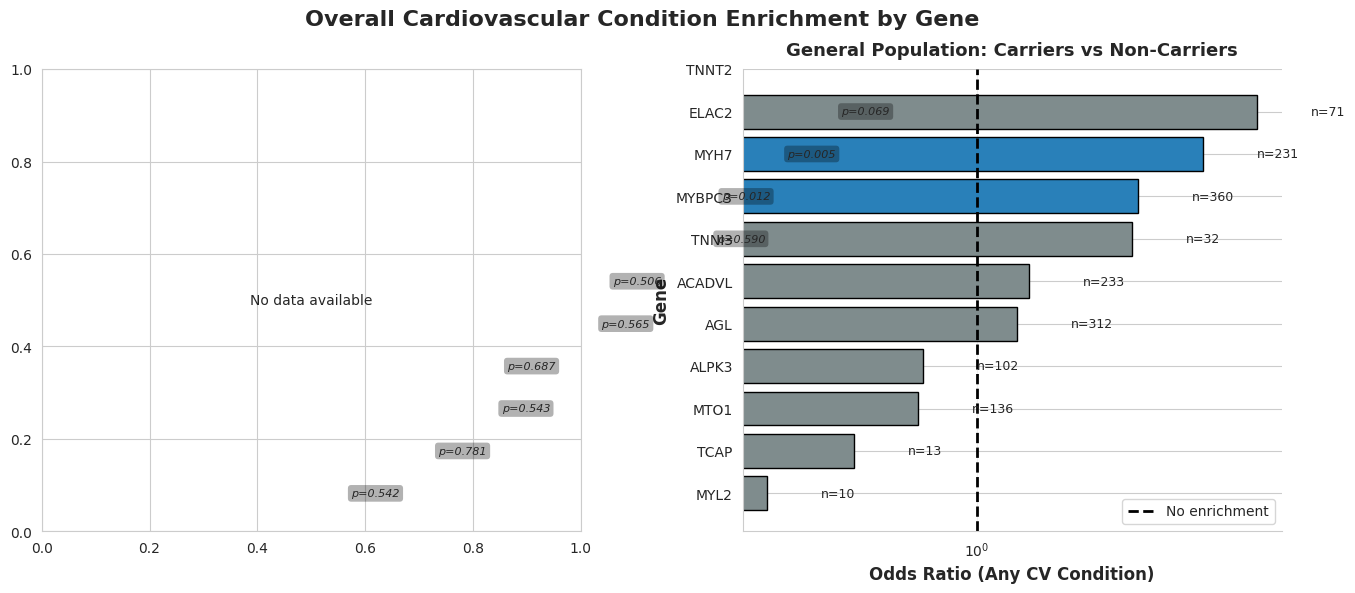


 Creating Figure 2: Top enriched conditions by gene (forest plots)...


/var/tmp/ipykernel_1833523/3813444815.py:150: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_conditions = df_sig.groupby('gene').apply(


   Saved: /home/jupyter/prs_hcm_experiment/plots/gene_stratified_forest_hcm.png


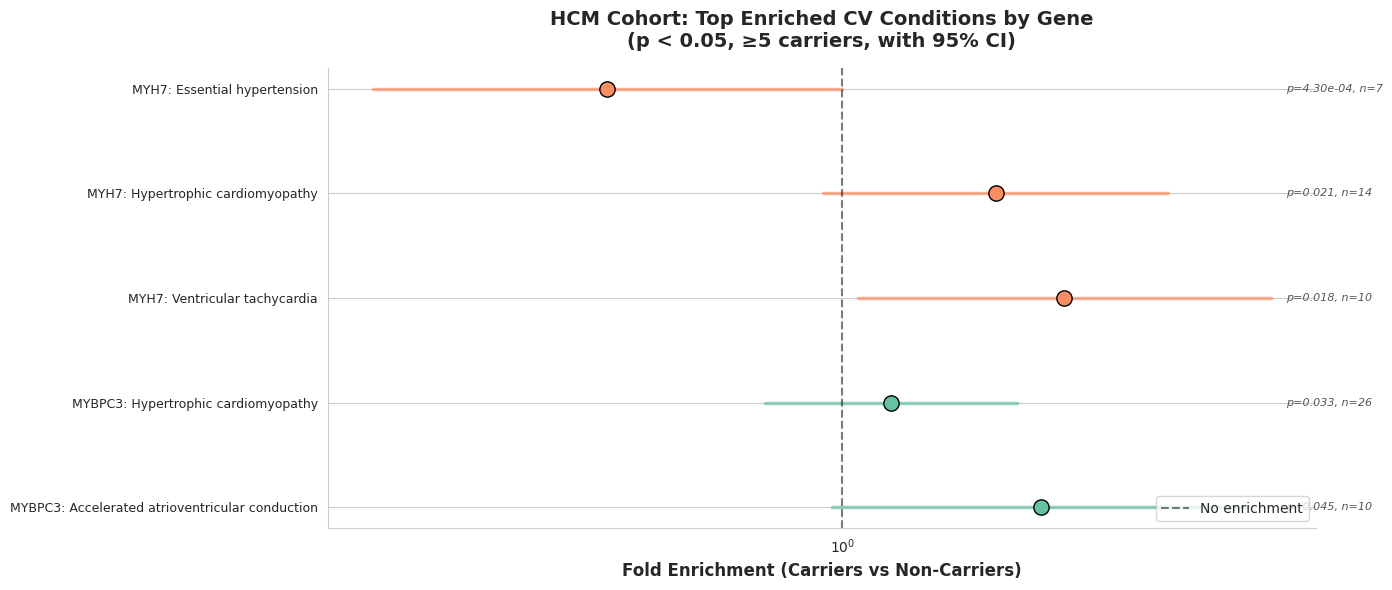

/var/tmp/ipykernel_1833523/3813444815.py:150: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_conditions = df_sig.groupby('gene').apply(


   Saved: /home/jupyter/prs_hcm_experiment/plots/gene_stratified_forest_genpop.png


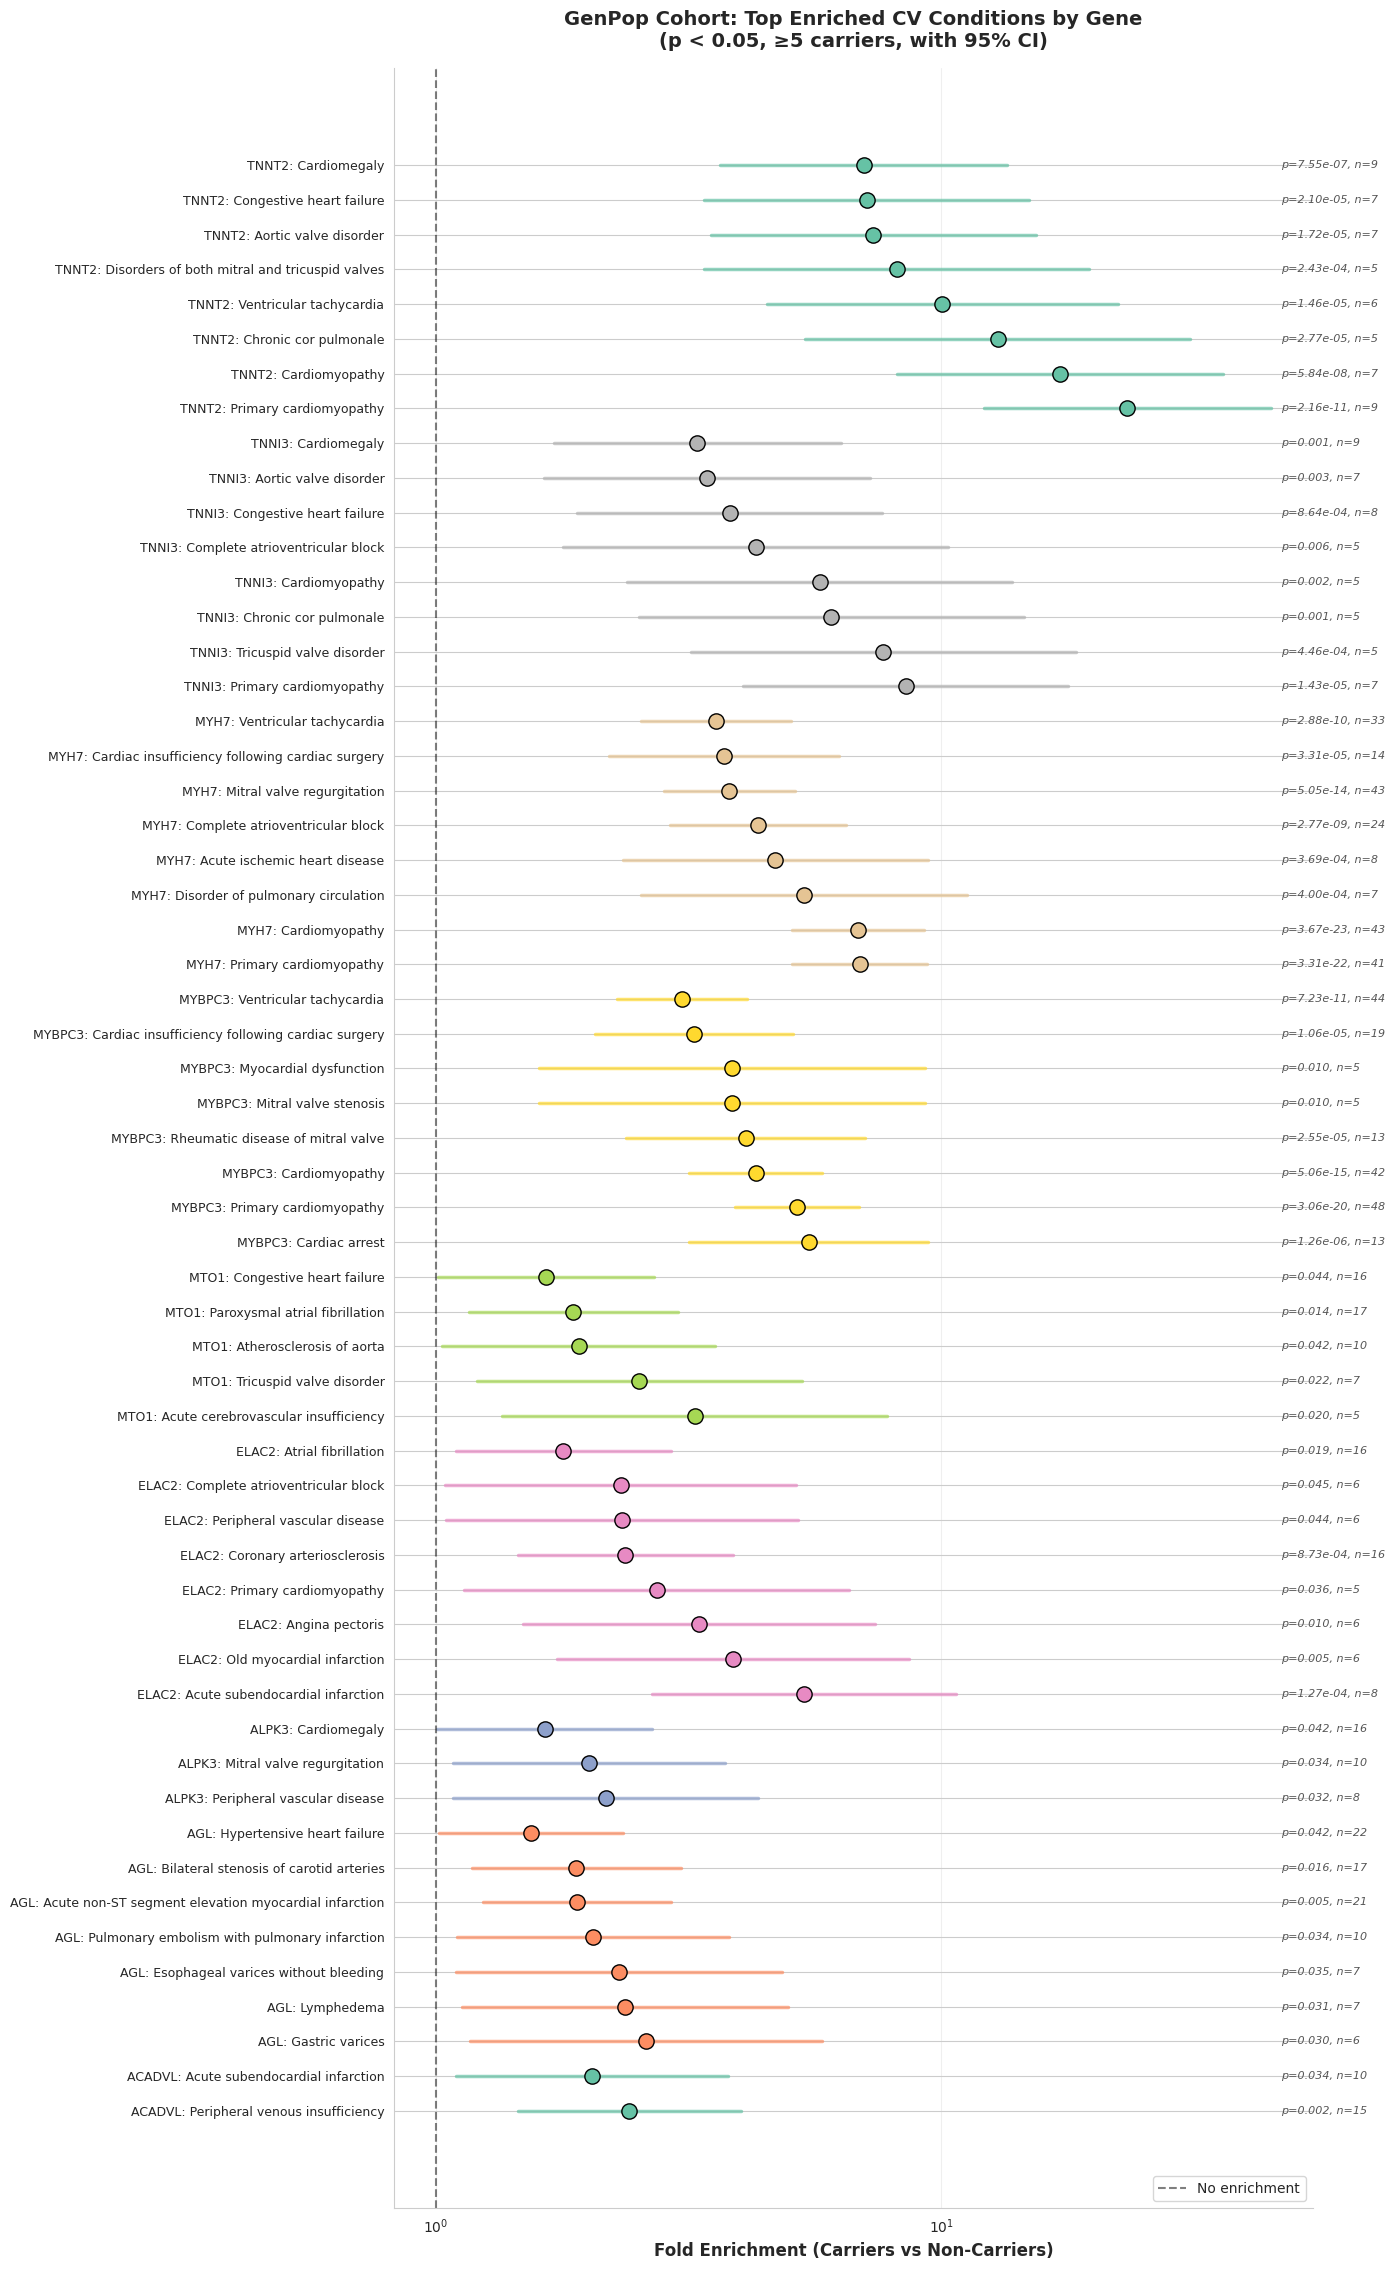


 Creating summary statistics table...

SUMMARY STATISTICS BY GENE:

MYBPC3:
   HCM Cohort:
      Carriers: 26 | Non-carriers: 285
      No data
   General Population:
      Carriers: 360 | Non-carriers: 248,272
      Overall OR: 1.33 (p=1.16e-02)
      Significant conditions: 37/140
      Top enrichment: Cerebral amyloid angiopathy (FE=8.96)

MYH7:
   HCM Cohort:
      Carriers: 20 | Non-carriers: 285
      No data
   General Population:
      Carriers: 231 | Non-carriers: 248,272
      Overall OR: 1.49 (p=4.80e-03)
      Significant conditions: 45/140
      Top enrichment: Rheumatic aortic stenosis (FE=7.29)

ACADVL:
   HCM Cohort:
      Carriers: 0 | Non-carriers: 0
      No data
   General Population:
      Carriers: 233 | Non-carriers: 248,272
      Overall OR: 1.10 (p=5.06e-01)
      Significant conditions: 4/140
      Top enrichment: Peripheral venous insufficiency (FE=2.41)

ALPK3:
   HCM Cohort:
      Carriers: 0 | Non-carriers: 0
      No data
   General Population:
      Car

In [52]:
# ============================================================================
# GENE-STRATIFIED ENRICHMENT VISUALIZATION
# ============================================================================
print("VISUALIZING GENE-STRATIFIED CV ENRICHMENT RESULTS")
import textwrap
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

# Load enrichment results
print("\n Loading enrichment results...")

hcm_file = "/home/jupyter/prs_hcm_experiment/clinical_analysis/hcm_cohort_gene_stratified_enrichment.tsv"
genpop_file = "/home/jupyter/prs_hcm_experiment/clinical_analysis/genpop_gene_stratified_enrichment.tsv"

hcm_df = pd.read_csv(hcm_file, sep='\t')
genpop_df = pd.read_csv(genpop_file, sep='\t')

print(f"   HCM cohort: {len(hcm_df)} condition-gene pairs across {hcm_df['gene'].nunique()} genes")
print(f"   General population: {len(genpop_df)} condition-gene pairs across {genpop_df['gene'].nunique()} genes")

# ============================================================================
# FIGURE 1: OVERALL ENRICHMENT BY GENE
# ============================================================================
print("\n Creating Figure 1: Overall CV enrichment by gene...")

def get_gene_overall_stats(df):
    """Extract overall enrichment statistics per gene"""
    gene_stats = df.groupby('gene').agg({
        'n_carriers': 'first',
        'n_noncarriers': 'first',
        'overall_OR': 'first',
        'overall_pvalue': 'first'
    }).reset_index()
    
    return gene_stats

hcm_gene_stats = get_gene_overall_stats(hcm_df)
genpop_gene_stats = get_gene_overall_stats(genpop_df)

# Create figure with adjusted layout
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 2, hspace=0.3, wspace=0.3)

# HCM Cohort
ax1 = fig.add_subplot(gs[0, 0])
hcm_gene_stats_sorted = hcm_gene_stats.sort_values('overall_OR', ascending=True)
colors_hcm = ['#c0392b' if p < 0.05 else '#7f8c8d' for p in hcm_gene_stats_sorted['overall_pvalue']]

# Check if we have valid OR values
if hcm_gene_stats_sorted['overall_OR'].notna().any():
    bars = ax1.barh(range(len(hcm_gene_stats_sorted)), hcm_gene_stats_sorted['overall_OR'], 
                    color=colors_hcm, edgecolor='black', linewidth=1)
    ax1.set_yticks(range(len(hcm_gene_stats_sorted)))
    ax1.set_yticklabels(hcm_gene_stats_sorted['gene'])
    
    ax1.axvline(x=1, color='black', linestyle='--', linewidth=2, label='No enrichment')
    ax1.set_xlabel('Odds Ratio (Any CV Condition)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Gene', fontsize=12, fontweight='bold')
    ax1.set_title('HCM Cohort: Carriers vs Non-Carriers', fontsize=13, fontweight='bold', pad=10)
    
    # Only use log scale if range is sufficient
    or_range = hcm_gene_stats_sorted['overall_OR'].max() / hcm_gene_stats_sorted['overall_OR'].min()
    if or_range > 2:
        ax1.set_xscale('log')
    
    ax1.grid(axis='x', alpha=0.3)
    ax1.legend(loc='lower right')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # Add sample sizes and p-values
    for i, (idx, row) in enumerate(hcm_gene_stats_sorted.iterrows()):
        x_pos = row['overall_OR'] * 1.1
        ax1.text(x_pos, i, f"n={int(row['n_carriers'])}", va='center', fontsize=9, ha='left')
        
        p_text = f"p={row['overall_pvalue']:.2e}" if row['overall_pvalue'] < 0.001 else f"p={row['overall_pvalue']:.3f}"
        # Position p-value on the bar itself
        ax1.text(row['overall_OR'] * 0.5, i, p_text, va='center', ha='center', fontsize=8, 
                style='italic', color='white' if row['overall_pvalue'] < 0.05 else 'black',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.3, edgecolor='none'))
else:
    ax1.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax1.transAxes)

# General Population
ax2 = fig.add_subplot(gs[0, 1])
genpop_gene_stats_sorted = genpop_gene_stats.sort_values('overall_OR', ascending=True)
colors_genpop = ['#2980b9' if p < 0.05 else '#7f8c8d' for p in genpop_gene_stats_sorted['overall_pvalue']]

if genpop_gene_stats_sorted['overall_OR'].notna().any():
    bars = ax2.barh(range(len(genpop_gene_stats_sorted)), genpop_gene_stats_sorted['overall_OR'], 
                    color=colors_genpop, edgecolor='black', linewidth=1)
    ax2.set_yticks(range(len(genpop_gene_stats_sorted)))
    ax2.set_yticklabels(genpop_gene_stats_sorted['gene'])
    
    ax2.axvline(x=1, color='black', linestyle='--', linewidth=2, label='No enrichment')
    ax2.set_xlabel('Odds Ratio (Any CV Condition)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Gene', fontsize=12, fontweight='bold')
    ax2.set_title('General Population: Carriers vs Non-Carriers', fontsize=13, fontweight='bold', pad=10)
    
    # Only use log scale if range is sufficient
    or_range = genpop_gene_stats_sorted['overall_OR'].max() / genpop_gene_stats_sorted['overall_OR'].min()
    if or_range > 2:
        ax2.set_xscale('log')
    
    ax2.grid(axis='x', alpha=0.3)
    ax2.legend(loc='lower right')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    # Add sample sizes and p-values
    for i, (idx, row) in enumerate(genpop_gene_stats_sorted.iterrows()):
        x_pos = row['overall_OR'] * 1.1
        ax2.text(x_pos, i, f"n={int(row['n_carriers'])}", va='center', fontsize=9, ha='left')
        
        p_text = f"p={row['overall_pvalue']:.2e}" if row['overall_pvalue'] < 0.001 else f"p={row['overall_pvalue']:.3f}"
        ax2.text(row['overall_OR'] * 0.5, i, p_text, va='center', ha='center', fontsize=8, 
                style='italic', bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.3, edgecolor='none'))
else:
    ax2.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax2.transAxes)

fig.suptitle('Overall Cardiovascular Condition Enrichment by Gene', 
             fontsize=16, fontweight='bold', y=0.98)

output_path = "/home/jupyter/prs_hcm_experiment/plots/gene_stratified_overall_enrichment.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ============================================================================
# FIGURE 2: FOREST PLOTS - TOP ENRICHED CONDITIONS BY GENE
# ============================================================================
print("\n Creating Figure 2: Top enriched conditions by gene (forest plots)...")

def create_forest_plot(df, cohort_name, top_n=8):
    """Create forest plot showing top N conditions per gene"""
    
    # Get significant enrichments
    df_sig = df[(df['pvalue'] < 0.05) & (df['carrier_count'] >= 5)].copy()
    
    if len(df_sig) == 0:
        print(f"   No significant enrichments found for {cohort_name}")
        return
    
    # Get top N conditions per gene by fold enrichment
    top_conditions = df_sig.groupby('gene').apply(
        lambda x: x.nlargest(min(top_n, len(x)), 'fold_enrichment')
    ).reset_index(drop=True)
    
    # Calculate 95% CI for fold enrichment
    def calc_ci(row):
        if row['carrier_count'] == 0 or row['noncarrier_count'] == 0:
            return pd.Series({'ci_lower': np.nan, 'ci_upper': np.nan})
        
        # Log transform for CI calculation
        log_fe = np.log(row['fold_enrichment'])
        se = np.sqrt(1/row['carrier_count'] + 1/row['noncarrier_count'])
        ci_lower = np.exp(log_fe - 1.96 * se)
        ci_upper = np.exp(log_fe + 1.96 * se)
        return pd.Series({'ci_lower': ci_lower, 'ci_upper': ci_upper})
    
    top_conditions[['ci_lower', 'ci_upper']] = top_conditions.apply(calc_ci, axis=1)
    
    # Create display labels
    top_conditions['label'] = (top_conditions['gene'] + ': ' + 
                                top_conditions['condition_name'].str[:55])
    
    # Sort by gene then fold enrichment
    top_conditions = top_conditions.sort_values(['gene', 'fold_enrichment'], 
                                                ascending=[True, False])
    
    # Create plot
    fig_height = max(6, len(top_conditions) * 0.4)
    fig, ax = plt.subplots(figsize=(14, fig_height))
    
    y_positions = np.arange(len(top_conditions))
    
    # Color by gene
    gene_colors = {gene: color for gene, color in 
                   zip(top_conditions['gene'].unique(), 
                       sns.color_palette("Set2", n_colors=top_conditions['gene'].nunique()))}
    colors = [gene_colors[gene] for gene in top_conditions['gene']]
    
    # Plot error bars and points
    for i, (idx, row) in enumerate(top_conditions.iterrows()):
        ax.plot([row['ci_lower'], row['ci_upper']], [y_positions[i], y_positions[i]], 
               color=colors[i], linewidth=2.5, alpha=0.7, solid_capstyle='round')
        ax.plot(row['fold_enrichment'], y_positions[i], 'o', 
               color=colors[i], markersize=11, markeredgecolor='black', markeredgewidth=1)
    
    # Reference line
    ax.axvline(x=1, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='No enrichment')
    
    # Formatting
    ax.set_yticks(y_positions)
    ax.set_yticklabels(top_conditions['label'], fontsize=9)
    ax.set_xlabel('Fold Enrichment (Carriers vs Non-Carriers)', fontsize=12, fontweight='bold')
    ax.set_title(f'{cohort_name} Cohort: Top Enriched CV Conditions by Gene\n(p < 0.05, ≥5 carriers, with 95% CI)', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xscale('log')
    ax.grid(axis='x', alpha=0.3)
    ax.legend(loc='lower right', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add p-values and sample sizes
    max_x = top_conditions['ci_upper'].max()
    for i, (idx, row) in enumerate(top_conditions.iterrows()):
        p_text = f"p={row['pvalue']:.2e}" if row['pvalue'] < 0.001 else f"p={row['pvalue']:.3f}"
        n_text = f"n={int(row['carrier_count'])}"
        ax.text(max_x * 1.05, y_positions[i], 
               f"{p_text}, {n_text}", va='center', fontsize=8, style='italic', color='#555555')
    
    plt.tight_layout()
    output_path = f"/home/jupyter/prs_hcm_experiment/plots/gene_stratified_forest_{cohort_name.lower()}.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"   Saved: {output_path}")
    plt.show()
    plt.close()

# Create forest plots for both cohorts
create_forest_plot(hcm_df, 'HCM', top_n=8)
create_forest_plot(genpop_df, 'GenPop', top_n=8)

# ============================================================================
# SUMMARY STATISTICS TABLE
# ============================================================================
print("\n Creating summary statistics table...")

summary_data = []

# Get all unique genes from both cohorts
all_genes = pd.concat([hcm_df['gene'], genpop_df['gene']]).unique()

for gene in sorted(all_genes):
    row = {'Gene': gene}
    
    # HCM cohort statistics
    if gene in hcm_df['gene'].values:
        hcm_gene = hcm_df[hcm_df['gene'] == gene]
        row['HCM_N_Carriers'] = int(hcm_gene['n_carriers'].iloc[0])
        row['HCM_N_NonCarriers'] = int(hcm_gene['n_noncarriers'].iloc[0])
        row['HCM_Overall_OR'] = round(hcm_gene['overall_OR'].iloc[0], 2)
        row['HCM_Overall_P'] = hcm_gene['overall_pvalue'].iloc[0]
        row['HCM_N_Sig_Conditions'] = int((hcm_gene['pvalue'] < 0.05).sum())
        row['HCM_N_Total_Conditions'] = len(hcm_gene)
        
        # Get top enriched condition
        top_hcm = hcm_gene.nlargest(1, 'fold_enrichment')
        row['HCM_Top_Condition'] = top_hcm['condition_name'].iloc[0] if len(top_hcm) > 0 else 'N/A'
        row['HCM_Top_FoldEnrich'] = round(top_hcm['fold_enrichment'].iloc[0], 2) if len(top_hcm) > 0 else np.nan
    else:
        row['HCM_N_Carriers'] = 0
        row['HCM_N_NonCarriers'] = 0
        row['HCM_Overall_OR'] = np.nan
        row['HCM_Overall_P'] = np.nan
        row['HCM_N_Sig_Conditions'] = 0
        row['HCM_N_Total_Conditions'] = 0
        row['HCM_Top_Condition'] = 'N/A'
        row['HCM_Top_FoldEnrich'] = np.nan
    
    # General population statistics
    if gene in genpop_df['gene'].values:
        gp_gene = genpop_df[genpop_df['gene'] == gene]
        row['GenPop_N_Carriers'] = int(gp_gene['n_carriers'].iloc[0])
        row['GenPop_N_NonCarriers'] = int(gp_gene['n_noncarriers'].iloc[0])
        row['GenPop_Overall_OR'] = round(gp_gene['overall_OR'].iloc[0], 2)
        row['GenPop_Overall_P'] = gp_gene['overall_pvalue'].iloc[0]
        row['GenPop_N_Sig_Conditions'] = int((gp_gene['pvalue'] < 0.05).sum())
        row['GenPop_N_Total_Conditions'] = len(gp_gene)
        
        # Get top enriched condition
        top_gp = gp_gene.nlargest(1, 'fold_enrichment')
        row['GenPop_Top_Condition'] = top_gp['condition_name'].iloc[0] if len(top_gp) > 0 else 'N/A'
        row['GenPop_Top_FoldEnrich'] = round(top_gp['fold_enrichment'].iloc[0], 2) if len(top_gp) > 0 else np.nan
    else:
        row['GenPop_N_Carriers'] = 0
        row['GenPop_N_NonCarriers'] = 0
        row['GenPop_Overall_OR'] = np.nan
        row['GenPop_Overall_P'] = np.nan
        row['GenPop_N_Sig_Conditions'] = 0
        row['GenPop_N_Total_Conditions'] = 0
        row['GenPop_Top_Condition'] = 'N/A'
        row['GenPop_Top_FoldEnrich'] = np.nan
    
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)

# Sort by HCM carrier count (descending)
summary_df = summary_df.sort_values('HCM_N_Carriers', ascending=False)

# Save to file
output_path = "/home/jupyter/prs_hcm_experiment/clinical_analysis/gene_stratified_summary_statistics.tsv"
summary_df.to_csv(output_path, sep='\t', index=False)

# Display summary
print("\nSUMMARY STATISTICS BY GENE:")
print("="*80)
for _, row in summary_df.iterrows():
    print(f"\n{row['Gene']}:")
    print(f"   HCM Cohort:")
    print(f"      Carriers: {row['HCM_N_Carriers']:,} | Non-carriers: {row['HCM_N_NonCarriers']:,}")
    if not pd.isna(row['HCM_Overall_OR']):
        print(f"      Overall OR: {row['HCM_Overall_OR']:.2f} (p={row['HCM_Overall_P']:.2e})")
        print(f"      Significant conditions: {row['HCM_N_Sig_Conditions']}/{row['HCM_N_Total_Conditions']}")
        if row['HCM_Top_Condition'] != 'N/A':
            print(f"      Top enrichment: {row['HCM_Top_Condition'][:60]} (FE={row['HCM_Top_FoldEnrich']:.2f})")
    else:
        print(f"      No data")
    
    print(f"   General Population:")
    print(f"      Carriers: {row['GenPop_N_Carriers']:,} | Non-carriers: {row['GenPop_N_NonCarriers']:,}")
    if not pd.isna(row['GenPop_Overall_OR']):
        print(f"      Overall OR: {row['GenPop_Overall_OR']:.2f} (p={row['GenPop_Overall_P']:.2e})")
        print(f"      Significant conditions: {row['GenPop_N_Sig_Conditions']}/{row['GenPop_N_Total_Conditions']}")
        if row['GenPop_Top_Condition'] != 'N/A':
            print(f"      Top enrichment: {row['GenPop_Top_Condition'][:60]} (FE={row['GenPop_Top_FoldEnrich']:.2f})")
    else:
        print(f"      No data")